# Warehouse

In [1317]:
import sqlite3
import pandas as pd

target_db = 'GreatOutdoors/SDM.sqlite'
target_WH_db = 'GreatOutdoors/Warehouse.sqlite'
# Connections
sdm_conn = sqlite3.connect(target_db)
dwh_conn = sqlite3.connect(target_WH_db)



## Customer Headquarters

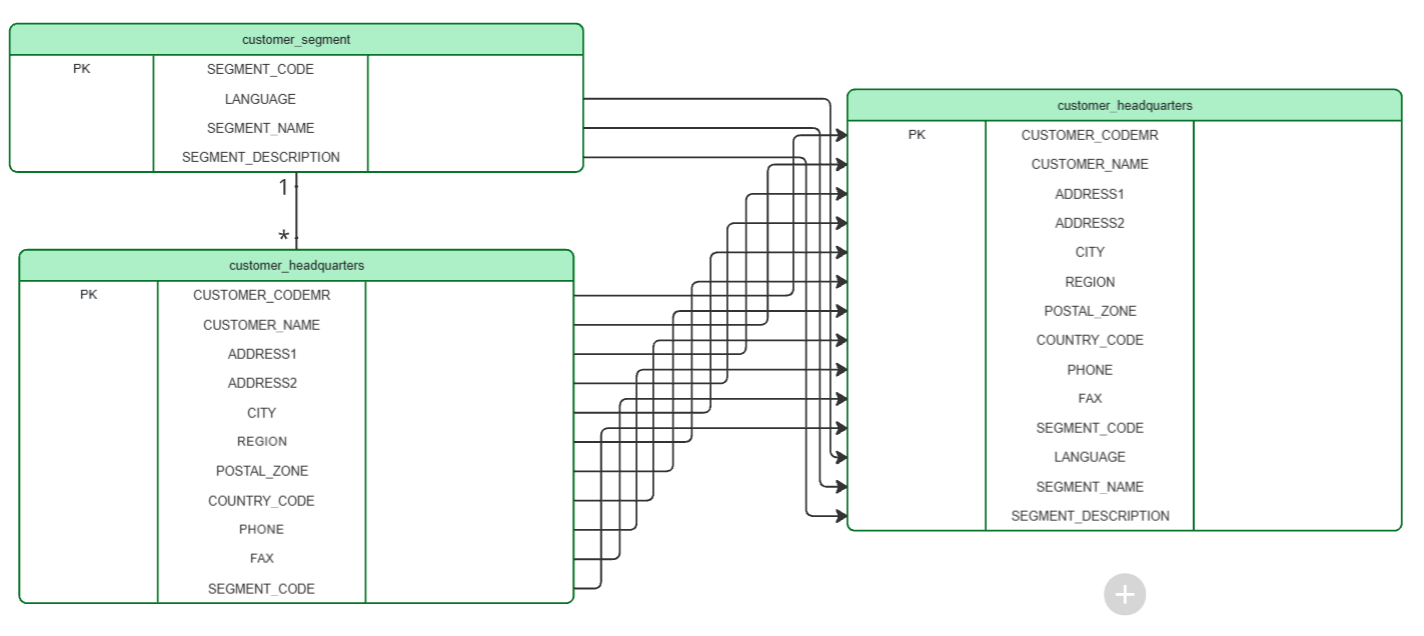

In [1318]:
df_customer_segment            = pd.read_sql_query("SELECT * FROM Customer_Segment", sdm_conn)
df_customer_headquarters = pd.read_sql_query("SELECT * FROM Customer_Headquarters", sdm_conn)

df_customer_headquarters_final = pd.merge(
    df_customer_headquarters,
    df_customer_segment,
    left_on='SEGMENT_CODE',
    right_on='SEGMENT_CODE',
    how='left')
df_customer_headquarters_final = df_customer_headquarters_final[[
    'CUSTOMER_CODEMR',
    'CUSTOMER_NAME',
    'ADDRESS1',
    'ADDRESS2',
    'CITY',
    'REGION',
    'POSTAL_ZONE',
    'COUNTRY_CODE',
    'PHONE',
    'FAX',
    'SEGMENT_CODE',
    'LANGUAGE',
    'SEGMENT_NAME',
    'SEGMENT_DESCRIPTION'
]]

df_customer_headquarters_final

,CUSTOMER_CODEMR,CUSTOMER_NAME,ADDRESS1,ADDRESS2,CITY,REGION,POSTAL_ZONE,COUNTRY_CODE,PHONE,FAX,SEGMENT_CODE,LANGUAGE,SEGMENT_NAME,SEGMENT_DESCRIPTION
0,442,Morro Sports,"Rua Texeira de Freitas, 1248",6 Andar,Rio de Janeiro,RJ,20031-050,21,+55 (21) 224-7999,+55 (21) 224-0986,12,EN,Sports Store,Primarily offers a wide range of sporting goods.
1,454,"Hangzhou Superman Sports Goods Co., LTD.",59 Yang Fang Dian West,Hai Dian District,Beijing,NaN,100038,14,86-10-6252-8387,86-10-6252-8387,3,EN,Golf Shop,Primarily offers golf equipment and accessories.
2,455,"Lan King Sports Co., LTD.",No.339 Huan Shi Dong Road,NaN,Guangzhou,GuangDong,510098,14,86-20-8331-3501,86-20-8331-3501,1,EN,Outdoors Shop - Exclusive,"Primarily offers camping supplies, hiking equi..."
3,456,"China Multi-channel Sports Co., LTD.",No.318 Huan Cheng Bei Road,NaN,Hangzhou,Zhejiang,310012,14,86-571-525-2443,86-571-525-2443,7,EN,Direct Marketing,Offers a wide range of goods through mail orde...
4,457,Great Dragon Group,No.88 Zhong Shan Road,NaN,Harbin,Helong,150049,14,86-451-277-6197,86-451-277-6196,10,EN,Eyewear Store,Primarily offers prescription and fashion eyew...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409,437,Esportes Grumari,"Alameda Santos, 9876",6o. Andar,São Paulo,SP,04571-010,21,+55 (11) 288-5032,+55 (11) 288-2345,5,EN,Department Store,Offers a wide range of goods.
410,438,Casa do Alpinista,"Rua Machado de Assis, 1987",2o. Andar,Porto Alegre,RS,55230-333,21,+55 (51) 333-4587,+55 (51) 333-7777,11,EN,Sports Store - Exclusive,Primarily offers a wide range of sporting good...
411,439,Mega Shop do Esporte,"Av. Presidente Wilson, 9999",10 Andar,Rio de Janeiro,RJ,20031-050,21,+55 (21) 332-5509,+55 (21) 332-9999,8,EN,Warehouse Store,Offers a wide range of goods in a large wareho...
412,440,Esportópolis,"Rua Estados Unidos, 998",Térreo,São Paulo,SP,05120-900,21,+55 (11) 878-2275,+55 (11) 878-2387,8,EN,Warehouse Store,Offers a wide range of goods in a large wareho...


In [1319]:
import sqlite3
import pandas as pd

# Ensure target_WH_db is defined earlier in your script
dwh_conn = sqlite3.connect(target_WH_db)

try:
    # 1. Read DWH and normalize columns
    df_dwh = pd.read_sql("SELECT * FROM Customer_Headquarters", dwh_conn)
    df_dwh.columns = df_dwh.columns.str.lower()
    
    # Normalize source columns
    src_df = df_customer_headquarters_final.copy()
    src_df.columns = src_df.columns.str.lower()

    # --- FIX: TYPE ALIGNMENT & TYPO ---
    # Convert SDM strings to numeric
    src_df['customer_codemr'] = pd.to_numeric(src_df['customer_codemr'], errors='coerce')
    
    # FIXED: Changed 'customer_contract_code' to 'customer_contact_code'
    src_df = src_df.dropna(subset=['customer_codemr'])
    src_df['customer_codemr'] = src_df['customer_codemr'].astype(int)
    # ---------------------------

    # 2. DETECT NEW ROWS
    new_rows = src_df[~src_df['customer_codemr'].isin(df_dwh['customer_codemr'])]

    # 3. DETECT CHANGES
    comparison = pd.merge(
        src_df, 
        df_dwh, 
        on='customer_codemr', 
        suffixes=('_src', '_dwh')
    )

    # Columns to check for changes
    cols_to_check = ['customer_name', 'address1', 'address2', 'city', 'region', 
        'postal_zone', 'country_code', 'phone', 'fax', 'segment_code', 
        'language', 'segment_name', 'segment_description']

    # Vectorized comparison
    # We use .fillna('') and .astype(str) to prevent NaN != NaN false positives
    src_comp = comparison[[f"{c}_src" for c in cols_to_check]].fillna('').astype(str)
    dwh_comp = comparison[[f"{c}_dwh" for c in cols_to_check]].fillna('').astype(str)
    
    changed_mask = (src_comp.values != dwh_comp.values).any(axis=1)
    changed_rows = comparison[changed_mask]

    # 4. THE LOAD
    if not new_rows.empty:
        # Only keep the original columns for the insert
        cols_to_keep = [c.lower() for c in df_customer_headquarters_final.columns]
        new_rows_to_insert = new_rows[cols_to_keep]
        new_rows_to_insert.to_sql('Customer_Headquarters', dwh_conn, if_exists='append', index=False)
        print(f"✨ Inserted {len(new_rows)} new customer_headquarters records.")

    if not changed_rows.empty:
        cursor = dwh_conn.cursor()
        
        # Prepare batch update data
        update_data = []
        for _, row in changed_rows.iterrows():
            update_data.append((
                row['customer_name_src'], row['address1_src'], row['address2_src'], 
                row['city_src'], row['region_src'], row['postal_zone_src'], 
                row['country_code_src'], row['phone_src'], row['fax_src'], 
                row['segment_code_src'], row['language_src'], row['segment_name_src'], 
                row['segment_description_src'],
                int(row['customer_codemr']) # The ID for the WHERE clause
            ))

        sql = """
            UPDATE Customer_Headquarters 
            SET customer_name = ?, address1 = ?, address2 = ?, city = ?, region = ?, 
                postal_zone = ?, country_code = ?, phone = ?, fax = ?, 
                segment_code = ?, language = ?, segment_name = ?, segment_description = ?
            WHERE customer_codemr = ?
        """
        cursor.executemany(sql, update_data)
        dwh_conn.commit()
        print(f"🔄 Updated {len(changed_rows)} existing rows (SCD Type 1).")
    
    if new_rows.empty and changed_rows.empty:
        print("ℹ️ No changes detected between SDM and DWH.")

except Exception as e:
    print(f"❌ An error occurred: {e}")

finally:
    dwh_conn.close()
    print("🔌 Connection closed safely.")

✨ Inserted 414 new customer_headquarters records.
🔌 Connection closed safely.


## Sales Demographic

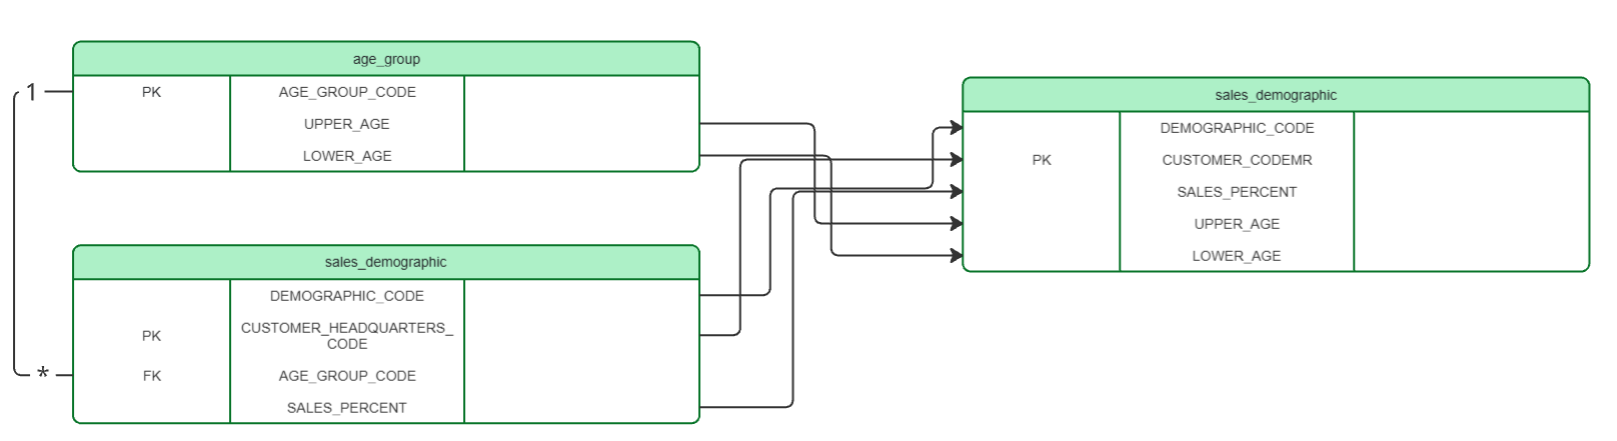

In [1320]:
df_age_group            = pd.read_sql_query("SELECT * FROM Age_Group", sdm_conn)
df_sales_demographic = pd.read_sql_query("SELECT * FROM Sales_Demographic", sdm_conn)

df_sales_demographic_final = pd.merge(
    df_sales_demographic,
    df_age_group,
    left_on='AGE_GROUP_CODE',
    right_on='AGE_GROUP_CODE',
    how='left')
df_sales_demographic_final = df_sales_demographic_final[[
    'DEMOGRAPHIC_CODE',
    'CUSTOMER_CODEMR',
    'SALES_PERCENT',
    'LOWER_AGE',
    'UPPER_AGE'
]]

df_sales_demographic_final

,DEMOGRAPHIC_CODE,CUSTOMER_CODEMR,SALES_PERCENT,LOWER_AGE,UPPER_AGE
0,2475,405,25,41,50
1,2476,405,23,51,60
2,2477,405,24,61,70
3,2478,412,2,0,20
4,2479,412,4,21,30
...,...,...,...,...,...
2479,2470,627,10,51,60
2480,2471,627,0,61,70
2481,2472,405,0,0,20
2482,2473,405,6,21,30


In [1321]:
import sqlite3
import pandas as pd

# Ensure target_WH_db is defined earlier in your script
dwh_conn = sqlite3.connect(target_WH_db)

try:
    # 1. Read DWH and normalize columns
    df_dwh = pd.read_sql("SELECT * FROM Sales_Demographic", dwh_conn)
    df_dwh.columns = df_dwh.columns.str.lower()
    
    # Normalize source columns
    src_df = df_sales_demographic_final.copy()
    src_df.columns = src_df.columns.str.lower()

    # --- FIX: TYPE ALIGNMENT & TYPO ---
    # Convert SDM strings to numeric
    src_df['demographic_code'] = pd.to_numeric(src_df['demographic_code'], errors='coerce')
    
    # FIXED: Changed 'customer_contract_code' to 'customer_contact_code'
    src_df = src_df.dropna(subset=['demographic_code'])
    src_df['demographic_code'] = src_df['demographic_code'].astype(int)
    # ---------------------------

    # 2. DETECT NEW ROWS
    new_rows = src_df[~src_df['demographic_code'].isin(df_dwh['demographic_code'])]

    # 3. DETECT CHANGES
    comparison = pd.merge(
        src_df, 
        df_dwh, 
        on='demographic_code', 
        suffixes=('_src', '_dwh')
    )

    # Columns to check for changes
    cols_to_check = ['customer_codemr', 'sales_percent', 'upper_age', 'lower_age']

    # Vectorized comparison
    # We use .fillna('') and .astype(str) to prevent NaN != NaN false positives
    src_comp = comparison[[f"{c}_src" for c in cols_to_check]].fillna('').astype(str)
    dwh_comp = comparison[[f"{c}_dwh" for c in cols_to_check]].fillna('').astype(str)
    
    changed_mask = (src_comp.values != dwh_comp.values).any(axis=1)
    changed_rows = comparison[changed_mask]

    # 4. THE LOAD
    if not new_rows.empty:
        # Only keep the original columns for the insert
        cols_to_keep = [c.lower() for c in df_sales_demographic_final.columns]
        new_rows_to_insert = new_rows[cols_to_keep]
        new_rows_to_insert.to_sql('Sales_Demographic', dwh_conn, if_exists='append', index=False)
        print(f"✨ Inserted {len(new_rows)} new sales_demographic records.")

    if not changed_rows.empty:
        cursor = dwh_conn.cursor()
        
        # Prepare batch update data
        update_data = []
        for _, row in changed_rows.iterrows():
            update_data.append((
                row['customer_codemr_src'], 
                row['sales_percent_src'], 
                row['upper_age_src'], 
                row['lower_age_src'],
                int(row['demographic_code']) # The ID for the WHERE clause
            ))

        sql = """
            UPDATE Sales_Demographic 
            SET customer_codemr = ?, sales_percent = ?, upper_age = ?, lower_age = ?
            WHERE demographic_code = ?
        """
        cursor.executemany(sql, update_data)
        dwh_conn.commit()
        print(f"🔄 Updated {len(changed_rows)} existing rows (SCD Type 1).")
    
    if new_rows.empty and changed_rows.empty:
        print("ℹ️ No changes detected between SDM and DWH.")

except Exception as e:
    print(f"❌ An error occurred: {e}")

finally:
    dwh_conn.close()
    print("🔌 Connection closed safely.")

✨ Inserted 2484 new sales_demographic records.
🔌 Connection closed safely.


## Customer

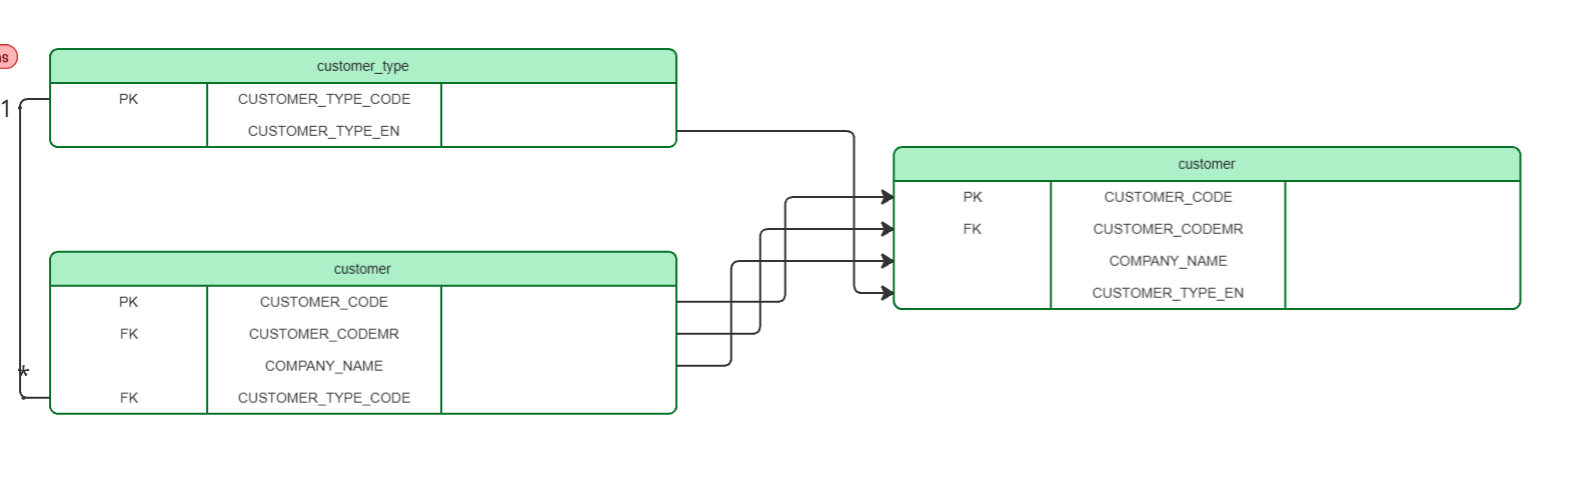

In [1322]:
df_customer_type = pd.read_sql_query("SELECT * FROM Customer_Type", sdm_conn)
df_customer = pd.read_sql_query("SELECT * FROM Customer", sdm_conn)

df_customer_final = pd.merge(
    df_customer,
    df_customer_type,
    left_on='CUSTOMER_TYPE_CODE',
    right_on='CUSTOMER_TYPE_CODE',
    how='left')

df_customer_final = df_customer_final.rename(columns={
    'CUSTOMER_TYPE_EN': 'CUSTOMER_TYPE'
})

df_customer_final = df_customer_final[[
    'CUSTOMER_CODE',
    'CUSTOMER_CODEMR',
    'COMPANY_NAME',
    'CUSTOMER_TYPE'
]]

df_customer_final

,CUSTOMER_CODE,CUSTOMER_CODEMR,COMPANY_NAME,CUSTOMER_TYPE
0,1,NaN,ActiForme,Equipment Rental Store
1,15,234,SportsClub,Golf Shop
2,23,229,Anapurna,Direct Marketing
3,32,230,Cordages Discount,Warehouse Store
4,33,228,Altitudes extrêmes,Outdoors Shop
...,...,...,...,...
104,193,428,Allo Allo,Direct Marketing
105,194,429,Caravanserai,Outdoors Shop
106,209,415,Ausrüstungshaus Globetrotter,Department Store
107,210,NaN,Golfer-Paradies,Golf Shop


In [1323]:
import sqlite3
import pandas as pd

# Ensure target_WH_db is defined earlier in your script
dwh_conn = sqlite3.connect(target_WH_db)

try:
    # 1. Read DWH and normalize columns
    df_dwh = pd.read_sql("SELECT * FROM Customer", dwh_conn)
    df_dwh.columns = df_dwh.columns.str.lower()
    
    # Normalize source columns
    src_df = df_customer_final.copy()
    src_df.columns = src_df.columns.str.lower()

    # --- FIX: TYPE ALIGNMENT & TYPO ---
    # Convert SDM strings to numeric
    src_df['customer_code'] = pd.to_numeric(src_df['customer_code'], errors='coerce')
    
    # FIXED: Changed 'customer_contract_code' to 'customer_contact_code'
    src_df = src_df.dropna(subset=['customer_code'])
    src_df['customer_code'] = src_df['customer_code'].astype(int)
    # ---------------------------

    # 2. DETECT NEW ROWS
    new_rows = src_df[~src_df['customer_code'].isin(df_dwh['customer_code'])]

    # 3. DETECT CHANGES
    comparison = pd.merge(
        src_df, 
        df_dwh, 
        on='customer_code', 
        suffixes=('_src', '_dwh')
    )

    # Columns to check for changes
    cols_to_check = ['customer_codemr', 'company_name', 'customer_type']

    # Vectorized comparison
    # We use .fillna('') and .astype(str) to prevent NaN != NaN false positives
    src_comp = comparison[[f"{c}_src" for c in cols_to_check]].fillna('').astype(str)
    dwh_comp = comparison[[f"{c}_dwh" for c in cols_to_check]].fillna('').astype(str)

    # DEBUG: Print the first 5 differences to see why it's flagging them
    for c in cols_to_check:
    # Convert both to numeric where possible, then to string to handle NaNs/Floats consistently
    # This turns 234.0 (float) and '234' (str) both into '234'
        comparison[f"{c}_src"] = pd.to_numeric(comparison[f"{c}_src"], errors='coerce').fillna(0).astype(int).astype(str)
        comparison[f"{c}_dwh"] = pd.to_numeric(comparison[f"{c}_dwh"], errors='coerce').fillna(0).astype(int).astype(str)

    # 2. Vectorized comparison
    src_comp = comparison[[f"{c}_src" for c in cols_to_check]]
    dwh_comp = comparison[[f"{c}_dwh" for c in cols_to_check]]
        
    changed_mask = (src_comp.values != dwh_comp.values).any(axis=1)
    changed_rows = comparison[changed_mask]

    # 4. THE LOAD
    if not new_rows.empty:
        # Only keep the original columns for the insert
        cols_to_keep = [c.lower() for c in df_customer_final.columns]
        new_rows_to_insert = new_rows[cols_to_keep]
        new_rows_to_insert.to_sql('Customer', dwh_conn, if_exists='append', index=False)
        print(f"✨ Inserted {len(new_rows)} new customers records.")

    if not changed_rows.empty:
        cursor = dwh_conn.cursor()
        
        # Prepare batch update data
        update_data = []
        for _, row in changed_rows.iterrows():
            update_data.append((
                row['customer_codemr_src'], 
                row['company_name_src'], 
                row['customer_type_src'],
                int(row['customer_code']) # The ID for the WHERE clause
            ))

        sql = """
             UPDATE Customer 
            SET customer_codemr = ?, company_name = ?, customer_type = ?
            WHERE customer_code = ?
        """
        cursor.executemany(sql, update_data)
        dwh_conn.commit()
        print(f"🔄 Updated {len(changed_rows)} existing rows (SCD Type 1).")
    
    if new_rows.empty and changed_rows.empty:
        print("ℹ️ No changes detected between SDM and DWH.")

except Exception as e:
    print(f"❌ An error occurred: {e}")

finally:
    dwh_conn.close()
    print("🔌 Connection closed safely.")

✨ Inserted 109 new customers records.
🔌 Connection closed safely.


## Sites

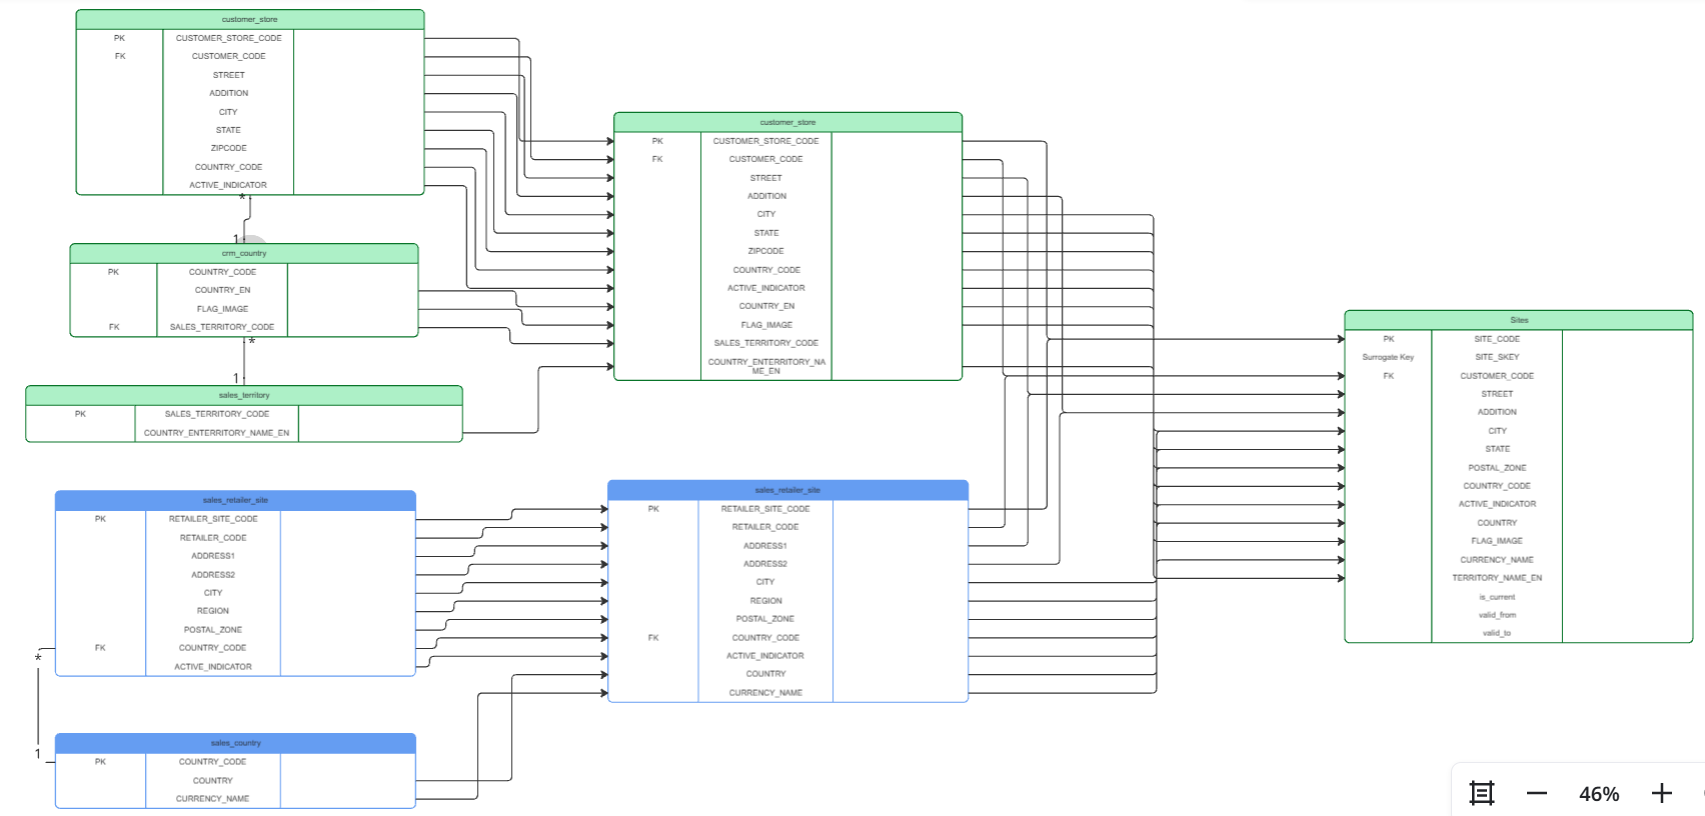

In [1324]:
## Customer Store Part

df_customer_store = pd.read_sql_query("SELECT * FROM Customer_Store", sdm_conn)
df_crm_country = pd.read_sql_query("SELECT * FROM CRM_Country", sdm_conn)
df_sales_territory = pd.read_sql_query("SELECT * FROM Sales_Territory", sdm_conn)

df_crm_country_final = pd.merge(
    df_crm_country,
    df_sales_territory,
    left_on='SALES_TERRITORY_CODE',
    right_on='SALES_TERRITORY_CODE',
    how='left')

df_customer_store_final = pd.merge(
    df_customer_store,
    df_crm_country_final,
    left_on='COUNTRY_CODE',
    right_on='COUNTRY_CODE',
    how='left')

#Fix the column names
# Both tables likely have a 'naam' column, so Pandas makes them 'naam_x' and 'naam_y'
df_customer_store_final = df_customer_store_final.rename(columns={
    'CUSTOMER_SITE_CODE': 'SITE_CODE',
    'ZIPCODE': 'POSTAL_ZONE',             # The accessory name
    'COUNTRY_EN': 'COUNTRY',
    'TERRITORY_NAME_EN': 'TERRITORY_NAME'  # The supplier name
})

df_customer_store_final = df_customer_store_final[[
    'SITE_CODE',
    'CUSTOMER_CODE',
    'STREET',
    'ADDITION',
    'CITY',
    'STATE',
    'POSTAL_ZONE',
    'COUNTRY_CODE',
    'ACTIVE_INDICATOR',
    'COUNTRY',
    'FLAG_IMAGE',
    'TERRITORY_NAME'
]]


## Retailer Site Part

df_retailer_site = pd.read_sql_query("SELECT * FROM Retailer_Site", sdm_conn)
df_country = pd.read_sql_query("SELECT * FROM Sales_Country", sdm_conn)

df_retailer_site_final = pd.merge(
    df_retailer_site,
    df_country,
    left_on='COUNTRY_CODE',
    right_on='COUNTRY_CODE',
    how='left')

#Fix the column names
# Both tables likely have a 'naam' column, so Pandas makes them 'naam_x' and 'naam_y'
df_retailer_site_final = df_retailer_site_final.rename(columns={
    'RETAILER_SITE_CODE': 'SITE_CODE',
    'RETAILER_CODE': 'CUSTOMER_CODE',
    'ADDRESS1': 'STREET',
    'ADDRESS2': 'ADDITION',             # The accessory name
    'REGION': 'STATE'  # The supplier name
})

df_retailer_site_final = df_retailer_site_final[[
    'SITE_CODE',
    'CUSTOMER_CODE',
    'STREET',
    'ADDITION',
    'CITY',
    'STATE',
    'POSTAL_ZONE',
    'COUNTRY_CODE',
    'ACTIVE_INDICATOR',
    'COUNTRY',
    'CURRENCY_NAME'
]]


# 1. Identify columns in Customer that ARE NOT in Retailer
# We keep 'SITE_CODE' because we need it to join!
unique_customer_cols = [col for col in df_customer_store_final.columns 
                        if col not in df_retailer_site_final.columns or col == 'SITE_CODE']

# 2. Merge only with those specific columns
df_site_final = pd.merge(
    df_retailer_site_final,
    df_customer_store_final[unique_customer_cols],
    on='SITE_CODE',
    how='left'
)
df_site_final

,SITE_CODE,CUSTOMER_CODE,STREET,ADDITION,CITY,STATE,POSTAL_ZONE,COUNTRY_CODE,ACTIVE_INDICATOR,COUNTRY,CURRENCY_NAME,FLAG_IMAGE,TERRITORY_NAME
0,1,89,1119 Franklin Blvd,NaN,Winnipeg,Manitoba,R2C 0M5,4,1,Canada,dollars,F04,Americas
1,2,89,"45, rue Atwater",NaN,Montréal,Québec,H2T 9K8,4,1,Canada,dollars,F04,Americas
2,3,89,328 Hodgson Road,NaN,Fredericton,New Brunswick,E3B 2H2,4,1,Canada,dollars,F04,Americas
3,4,90,"2425, rue Peel",NaN,Montréal,Québec,H4G 3T4,4,1,Canada,dollars,F04,Americas
4,5,90,34 8th Avenue,NaN,Sudbury,Ontario,M5V 1G5,4,1,Canada,dollars,F04,Americas
...,...,...,...,...,...,...,...,...,...,...,...,...,...
386,439,209,Hüttenstraße 87,NaN,Klosterneuburg,NaN,A-3400,5,1,Austria,schillings,F05,Southern Europe
387,440,209,Hauptstraße 85,NaN,Linz,NaN,A-4015,5,1,Austria,schillings,F05,Southern Europe
388,441,209,Amselweg 8,NaN,Innsbruck,NaN,A-6020,5,1,Austria,schillings,F05,Southern Europe
389,442,209,Hasengasse 38,NaN,Ischgl,NaN,A-6561,5,1,Austria,schillings,F05,Southern Europe


In [1325]:
import sqlite3
import pandas as pd
from datetime import datetime

# Settings
today = datetime.now().strftime('%Y-%m-%d')

def run_scd2_sites(df_source, db_path):
    print("🏁 Function started...")
    conn = sqlite3.connect(db_path)
    is_initial_load = False
    
    # CRUCIAL FIX: Normalize source columns immediately at the start
    df_source.columns = df_source.columns.str.lower()
    
    try:
        # 1. Check if the table is empty
        cursor = conn.cursor()
        cursor.execute("SELECT COUNT(*) FROM Sites")
        row_count = cursor.fetchone()[0]
        
        if row_count == 0:
            print("📭 Table exists but is EMPTY. Setting as Initial Load.")
            is_initial_load = True
            df_dwh = pd.DataFrame(columns=df_source.columns)
        else:
            print(f"🗂️ Table contains {row_count} rows. Processing as Incremental Load.")
            df_dwh = pd.read_sql("SELECT * FROM Sites WHERE is_current = 1", conn)
            df_dwh.columns = df_dwh.columns.str.lower()
            
            # Ensure site_code types match exactly
            df_dwh['site_code'] = pd.to_numeric(df_dwh['site_code'], errors='coerce').fillna(0).astype(int)
            
        # Ensure source site_code type matches exactly
        df_source['site_code'] = pd.to_numeric(df_source['site_code'], errors='coerce').fillna(0).astype(int)
            
    except Exception as db_err:
        print(f"⚠️ Table does not exist yet (Initial Load): {db_err}")
        is_initial_load = True
        df_dwh = pd.DataFrame(columns=df_source.columns)

    try:
        # 2. Identify NEW records
        df_new_site = df_source[~df_source['site_code'].isin(df_dwh['site_code'])].copy()

        # 3. Identify CHANGED records
        merged = pd.merge(df_source, df_dwh, on='site_code', suffixes=('_src', '_dwh'))
        
        common_cols = [c for c in df_source.columns if c in df_dwh.columns and c != 'site_code' and c != 'site_skey']
        change_mask = pd.Series([False] * len(merged))
        
        for col in common_cols:
            src_val = merged[f'{col}_src'].fillna('').astype(str).replace(['nan', 'None', '<NA>'], '').str.strip()
            dwh_val = merged[f'{col}_dwh'].fillna('').astype(str).replace(['nan', 'None', '<NA>'], '').str.strip()
            change_mask |= (src_val != dwh_val)

        changed_ids = merged.loc[change_mask, 'site_code'].unique().tolist()

        # 4. Handle Deactivations for updates
        cursor = conn.cursor()
        if changed_ids:
            for m_id in changed_ids:
                cursor.execute("""
                    UPDATE Sites 
                    SET is_current = 0, valid_to = ? 
                    WHERE site_code = ? AND is_current = 1
                """, (today, int(m_id)))
            conn.commit()

        df_updates = df_source[df_source['site_code'].isin(changed_ids)].copy()
        df_to_insert = pd.concat([df_new_site, df_updates], ignore_index=True)

        # 5. Populate metadata and execute write
        if not df_to_insert.empty:
            df_to_insert['is_current'] = 1
            df_to_insert['valid_from'] = today
            df_to_insert['valid_to'] = '9999-12-31'
            
            if is_initial_load:
                df_to_insert['site_skey'] = df_to_insert['site_code']
                print("✨ Forcing 'site_skey' to equal 'site_code' for Initial Load alignment.")
            else:
                if 'site_skey' in df_to_insert.columns:
                    df_to_insert = df_to_insert.drop(columns=['site_skey'])

            df_to_insert.to_sql('Sites', conn, if_exists='append', index=False)
            print(f"🚀 {len(df_to_insert)} records processed (New: {len(df_new_site)}, Updates: {len(df_updates)}).")
        else:
            print("ℹ️ No changes detected.")
            
    except Exception as master_e:
        print(f"❌ CRITICAL PIPELINE ERROR: {master_e}")
        
    finally:
        conn.close()
        print("🔌 Connection closed safely.")

run_scd2_sites(df_site_final, target_WH_db)

🏁 Function started...
📭 Table exists but is EMPTY. Setting as Initial Load.
✨ Forcing 'site_skey' to equal 'site_code' for Initial Load alignment.
🚀 391 records processed (New: 391, Updates: 0).
🔌 Connection closed safely.


## Customer Contact

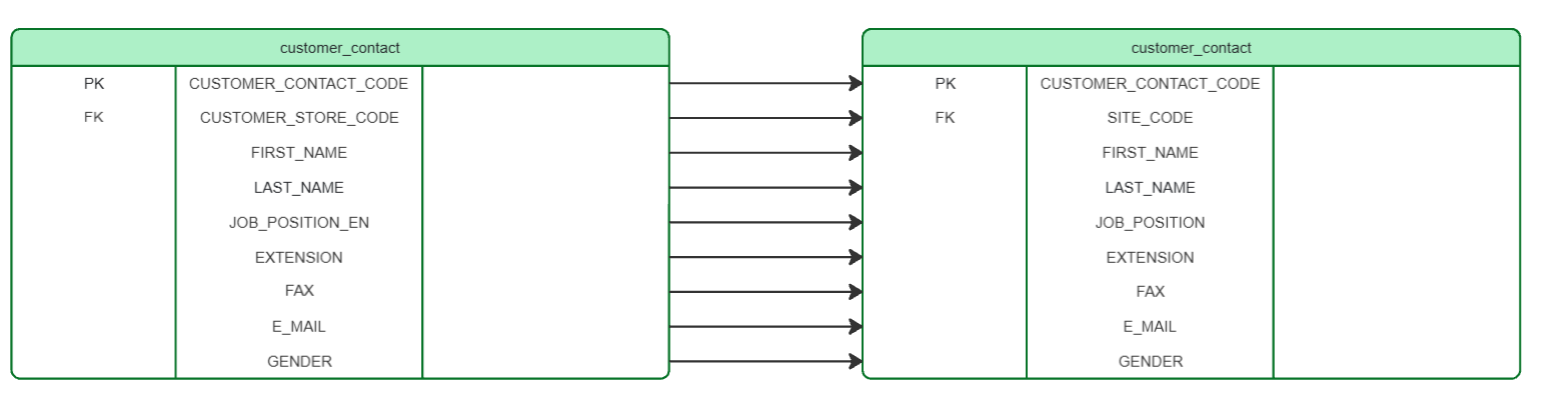

In [1326]:
df_customer_contact = pd.read_sql_query("SELECT * FROM Customer_Contact", sdm_conn)


#Fix the column names
# Both tables likely have a 'naam' column, so Pandas makes them 'naam_x' and 'naam_y'
df_customer_contact = df_customer_contact.rename(columns={
    'CUSTOMER_SITE_CODE': 'SITE_CODE',
    'JOB_POSITION_EN':'JOB_POSITION'
})

df_customer_contact = df_customer_contact[[
    'CUSTOMER_CONTACT_CODE',
    'SITE_CODE',
    'FIRST_NAME',
    'LAST_NAME',
    'JOB_POSITION',
    'EXTENSION',
    'FAX',
    'E_MAIL',
    'GENDER'
]]

df_customer_contact

,CUSTOMER_CONTACT_CODE,SITE_CODE,FIRST_NAME,LAST_NAME,JOB_POSITION,EXTENSION,FAX,E_MAIL,GENDER
0,399,391,Alison,Day,Site Assistant Manager,NaN,+(44) 171 6038084,ADay@outex99.com,F
1,400,392,Paul,Murphy,Site Manager,NaN,+(44) 1908 314014,Paul@jensenmountaineering.com,M
2,401,393,Joanne,Wallen,Chief Purchaser,NaN,+(44) 1489 790458,JWallen@beckssportsstore.com,F
3,402,394,Michael,Covington,Site Assistant Manager,NaN,+(44) 1865 891370,MCovington@brownsopticals.com,M
4,403,395,Colin,Barker,Site Assistant Manager,NaN,+(44) 181 6906670,CBarker@brownsopticals.com,M
...,...,...,...,...,...,...,...,...,...
386,394,386,Lee,Hong,Chief Purchaser,NaN,+(44) 171 3871873,Lee@jensenmountaineering.com,M
387,395,387,Karen,Posselwaite,Assistant Purchaser,NaN,+(44) 121 3607074,KP@lltnuble.com,F
388,396,388,Hillary,Thomas,Chief Purchaser,NaN,+(44) 117 9755453,HThomas@hurstironmongers.com,F
389,397,389,Jill,Sutherland,Site Manager,NaN,+(44) 171 9874611,JSutherland@hurstironmongers.com,F


In [1327]:
import sqlite3
import pandas as pd

# Ensure target_WH_db is defined earlier in your script
dwh_conn = sqlite3.connect(target_WH_db)

try:
    # 1. Read DWH and normalize columns
    df_dwh = pd.read_sql("SELECT * FROM Customer_Contact", dwh_conn)
    df_dwh.columns = df_dwh.columns.str.lower()
    
    # Normalize source columns
    src_df = df_customer_contact.copy()
    src_df.columns = src_df.columns.str.lower()

    # --- FIX: TYPE ALIGNMENT & TYPO ---
    # Convert SDM strings to numeric
    src_df['customer_contact_code'] = pd.to_numeric(src_df['customer_contact_code'], errors='coerce')
    
    # FIXED: Changed 'customer_contract_code' to 'customer_contact_code'
    src_df = src_df.dropna(subset=['customer_contact_code'])
    src_df['customer_contact_code'] = src_df['customer_contact_code'].astype(int)
    # ---------------------------

    # 2. DETECT NEW ROWS
    new_rows = src_df[~src_df['customer_contact_code'].isin(df_dwh['customer_contact_code'])]

    # 3. DETECT CHANGES
    comparison = pd.merge(
        src_df, 
        df_dwh, 
        on='customer_contact_code', 
        suffixes=('_src', '_dwh')
    )

    # Columns to check for changes
    cols_to_check = ['site_code', 'first_name', 'last_name', 'job_position', 'extension', 'fax', 'e_mail', 'gender']

    # Vectorized comparison
    # We use .fillna('') and .astype(str) to prevent NaN != NaN false positives
    src_comp = comparison[[f"{c}_src" for c in cols_to_check]].fillna('').astype(str)
    dwh_comp = comparison[[f"{c}_dwh" for c in cols_to_check]].fillna('').astype(str)
    
    changed_mask = (src_comp.values != dwh_comp.values).any(axis=1)
    changed_rows = comparison[changed_mask]

    # 4. THE LOAD
    if not new_rows.empty:
        # Only keep the original columns for the insert
        cols_to_keep = [c.lower() for c in df_customer_contact.columns]
        new_rows_to_insert = new_rows[cols_to_keep]
        new_rows_to_insert.to_sql('Customer_Contact', dwh_conn, if_exists='append', index=False)
        print(f"✨ Inserted {len(new_rows)} new customer_contact records.")

    if not changed_rows.empty:
        cursor = dwh_conn.cursor()
        
        # Prepare batch update data
        update_data = []
        for _, row in changed_rows.iterrows():
            update_data.append((
                row['site_code_src'], 
                row['first_name_src'], 
                row['last_name_src'], 
                row['job_position_src'], 
                row['extension_src'],
                row['fax_src'],
                row['e_mail_src'],
                row['gender_src'],
                int(row['customer_contact_code']) # The ID for the WHERE clause
            ))

        sql = """
            UPDATE Customer_Contact 
            SET site_code = ?, first_name = ?, last_name = ?, job_position = ?, extension = ?, fax = ?, e_mail = ?, gender = ?
            WHERE customer_contact_code = ?
        """
        cursor.executemany(sql, update_data)
        dwh_conn.commit()
        print(f"🔄 Updated {len(changed_rows)} existing rows (SCD Type 1).")
    
    if new_rows.empty and changed_rows.empty:
        print("ℹ️ No changes detected between SDM and DWH.")

except Exception as e:
    print(f"❌ An error occurred: {e}")

finally:
    dwh_conn.close()
    print("🔌 Connection closed safely.")

✨ Inserted 391 new customer_contact records.
🔌 Connection closed safely.


## Sales


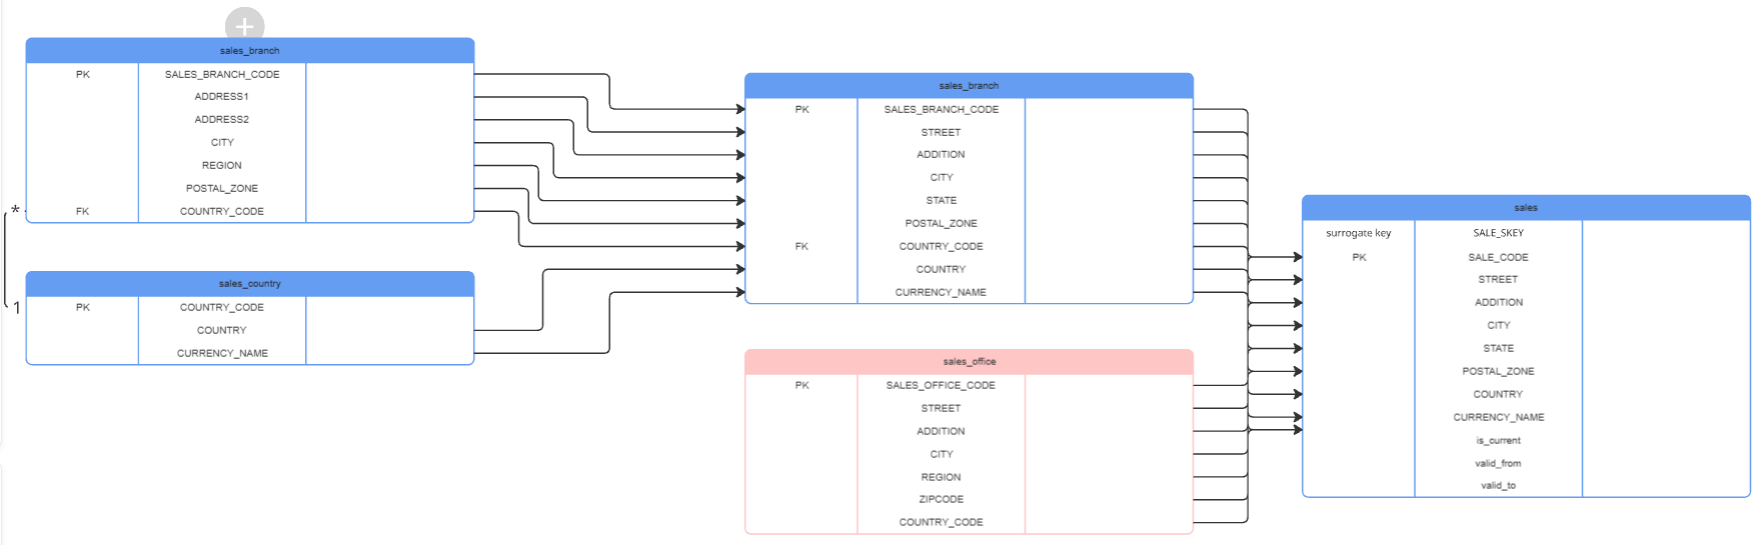

In [1328]:
## Customer Store Part

df_sales_branch = pd.read_sql_query("SELECT * FROM Sales_Branch", sdm_conn)
df_country = pd.read_sql_query("SELECT * FROM Sales_Country", sdm_conn)

df_sales_branch_final = pd.merge(
    df_sales_branch,
    df_country,
    left_on='COUNTRY_CODE',
    right_on='COUNTRY_CODE',
    how='left')

#Fix the column names
# Both tables likely have a 'naam' column, so Pandas makes them 'naam_x' and 'naam_y'
df_sales_branch_final = df_sales_branch_final.rename(columns={
    'SALES_BRANCH_CODE': 'SALE_CODE',
    'ADDRESS1': 'STREET',             # The accessory name
    'ADDRESS2': 'ADDITION',
    'REGION': 'STATE'  # The supplier name
})

df_sales_branch_final = df_sales_branch_final[[
    'SALE_CODE',
    'STREET',
    'ADDITION',
    'CITY',
    'POSTAL_ZONE',
    'COUNTRY',
    'CURRENCY_NAME'
]]


## Retailer Site Part

df_sales_office = pd.read_sql_query("SELECT * FROM Sales_Office", sdm_conn)

#Fix the column names
# Both tables likely have a 'naam' column, so Pandas makes them 'naam_x' and 'naam_y'
df_sales_office = df_sales_office.rename(columns={
    'SALES_OFFICE_CODE': 'SALE_CODE',
    'REGION': 'STATE',
    'ZIPCODE': 'POSTAL_ZONE'  # The supplier name
})

df_sales_office = df_sales_office[[
    'SALE_CODE',
    'STREET',
    'ADDITION',
    'CITY',
    'STATE',
    'POSTAL_ZONE'
]]


# 1. Identify columns in Customer that ARE NOT in Retailer
# We keep 'SITE_CODE' because we need it to join!
unique_sales_cols = [col for col in df_sales_branch_final.columns 
                        if col not in df_sales_office.columns or col == 'SALE_CODE']

# 2. Merge only with those specific columns
df_sale_final = pd.merge(
    df_sales_office,
    df_sales_branch_final[unique_sales_cols],
    on='SALE_CODE',
    how='left'
)
df_sale_final

,SALE_CODE,STREET,ADDITION,CITY,STATE,POSTAL_ZONE,COUNTRY,CURRENCY_NAME
0,6,"75, rue du Faubourg St-Honoré",NaN,Paris,NaN,F-75008,France,francs
1,7,"Piazza Duomo, 1",NaN,Milano,NaN,I-20121,Italy,lira
2,9,Singelgravenplein 4,4e verdieping,Amsterdam,Noord-Holland,1233 BW,Netherlands,guilders
3,13,Schwabentor 35,NaN,Hamburg,NaN,D-22529,Germany,marks
4,14,Leopoldstraße 36,NaN,München,NaN,D-81241,Germany,marks
5,15,Isafjordsgatan 30 C,NaN,Kista,NaN,S-164 40,Sweden,krona
6,17,"7800, 756 - 6th Avenue. S.W.",NaN,Calgary,Alberta,T2P 3Z0,Canada,dollars
7,18,789 Yonge Street,NaN,Toronto,Ontario,M2M 4K8,Canada,dollars
8,19,1288 Dorchester Avenue,NaN,Boston,Massachusetts,02133,United States,dollars
9,20,299 Yale Avenue,NaN,Seattle,Washington,98139,United States,dollars


In [1329]:
import sqlite3
import pandas as pd
from datetime import datetime

# Settings
today = datetime.now().strftime('%Y-%m-%d')

def run_scd2_sales(df_source, db_path):
    print("🏁 Function started...")
    conn = sqlite3.connect(db_path)
    is_initial_load = False
    
    # CRUCIAL FIX: Normalize source columns immediately at the start
    df_source.columns = df_source.columns.str.lower()
    
    try:
        # 1. Check if the table is empty
        cursor = conn.cursor()
        cursor.execute("SELECT COUNT(*) FROM Sales")
        row_count = cursor.fetchone()[0]
        
        if row_count == 0:
            print("📭 Table exists but is EMPTY. Setting as Initial Load.")
            is_initial_load = True
            df_dwh = pd.DataFrame(columns=df_source.columns)
        else:
            print(f"🗂️ Table contains {row_count} rows. Processing as Incremental Load.")
            df_dwh = pd.read_sql("SELECT * FROM Sales WHERE is_current = 1", conn)
            df_dwh.columns = df_dwh.columns.str.lower()
            
            # Ensure sale_code types match exactly
            df_dwh['sale_code'] = pd.to_numeric(df_dwh['sale_code'], errors='coerce').fillna(0).astype(int)
            
        # Ensure source sale_code type matches exactly
        df_source['sale_code'] = pd.to_numeric(df_source['sale_code'], errors='coerce').fillna(0).astype(int)
            
    except Exception as db_err:
        print(f"⚠️ Table does not exist yet (Initial Load): {db_err}")
        is_initial_load = True
        df_dwh = pd.DataFrame(columns=df_source.columns)

    try:
        # 2. Identify NEW records
        df_new_sale = df_source[~df_source['sale_code'].isin(df_dwh['sale_code'])].copy()

        # 3. Identify CHANGED records
        merged = pd.merge(df_source, df_dwh, on='sale_code', suffixes=('_src', '_dwh'))
        
        common_cols = [c for c in df_source.columns if c in df_dwh.columns and c != 'sale_code' and c != 'sale_skey']
        change_mask = pd.Series([False] * len(merged))
        
        for col in common_cols:
            src_val = merged[f'{col}_src'].fillna('').astype(str).replace(['nan', 'None', '<NA>'], '').str.strip()
            dwh_val = merged[f'{col}_dwh'].fillna('').astype(str).replace(['nan', 'None', '<NA>'], '').str.strip()
            change_mask |= (src_val != dwh_val)

        changed_ids = merged.loc[change_mask, 'sale_code'].unique().tolist()

        # 4. Handle Deactivations for updates
        cursor = conn.cursor()
        if changed_ids:
            for m_id in changed_ids:
                cursor.execute("""
                    UPDATE Sales 
                    SET is_current = 0, valid_to = ? 
                    WHERE sale_code = ? AND is_current = 1
                """, (today, int(m_id)))
            conn.commit()

        df_updates = df_source[df_source['sale_code'].isin(changed_ids)].copy()
        df_to_insert = pd.concat([df_new_sale, df_updates], ignore_index=True)

        # 5. Populate metadata and execute write
        if not df_to_insert.empty:
            df_to_insert['is_current'] = 1
            df_to_insert['valid_from'] = today
            df_to_insert['valid_to'] = '9999-12-31'
            
            if is_initial_load:
                df_to_insert['sale_skey'] = df_to_insert['sale_code']
                print("✨ Forcing 'sale_skey' to equal 'sale_code' for Initial Load alignment.")
            else:
                if 'sale_skey' in df_to_insert.columns:
                    df_to_insert = df_to_insert.drop(columns=['sale_skey'])

            df_to_insert.to_sql('Sales', conn, if_exists='append', index=False)
            print(f"🚀 {len(df_to_insert)} records processed (New: {len(df_new_sale)}, Updates: {len(df_updates)}).")
        else:
            print("ℹ️ No changes detected.")
            
    except Exception as master_e:
        print(f"❌ CRITICAL PIPELINE ERROR: {master_e}")
        
    finally:
        conn.close()
        print("🔌 Connection closed safely.")

run_scd2_sales(df_sale_final, target_WH_db)

🏁 Function started...
📭 Table exists but is EMPTY. Setting as Initial Load.
✨ Forcing 'sale_skey' to equal 'sale_code' for Initial Load alignment.
🚀 28 records processed (New: 28, Updates: 0).
🔌 Connection closed safely.


## Staff

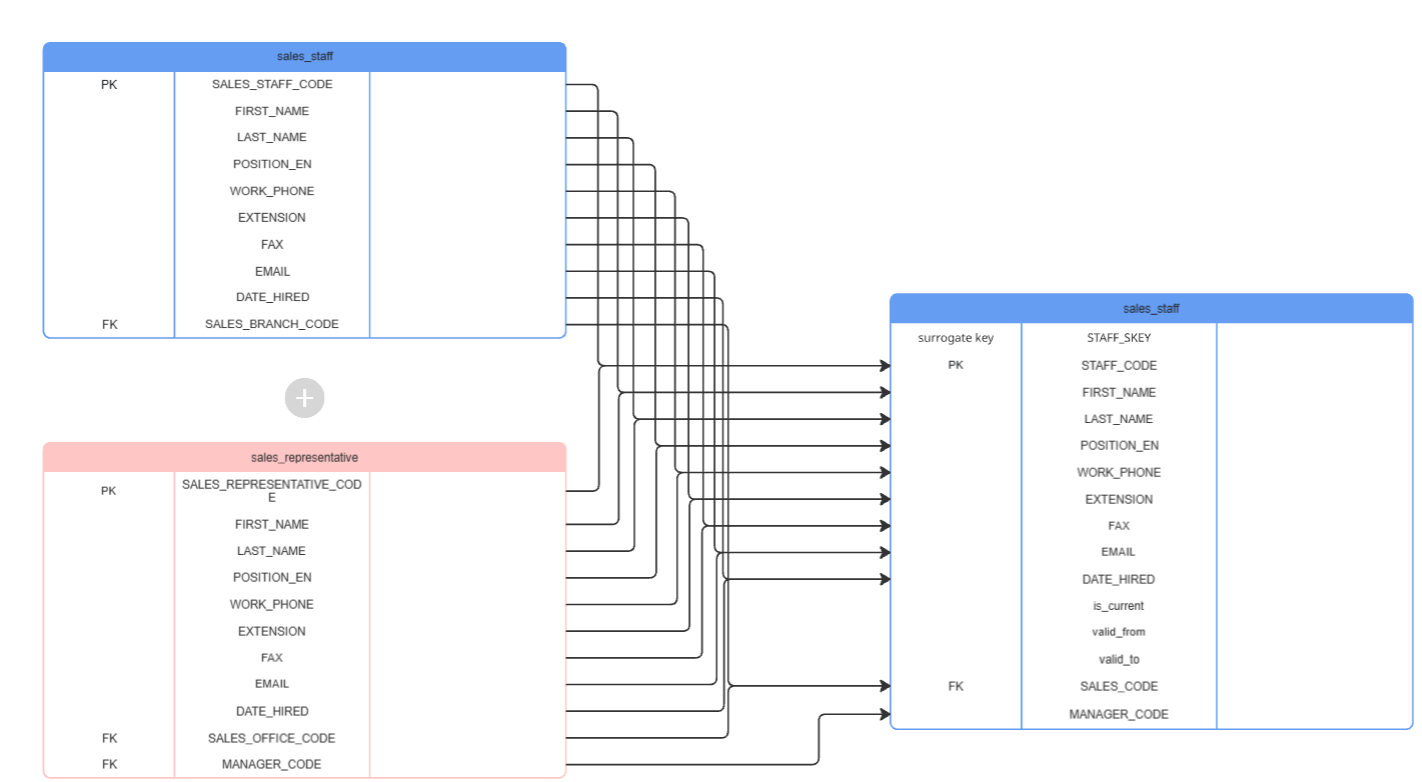

In [1344]:
df_sales_staff = pd.read_sql_query("SELECT * FROM Sales_Staff", sdm_conn)
df_sales_representative = pd.read_sql_query("SELECT * FROM Sales_Representative", sdm_conn)

#Fix the column names
# Both tables likely have a 'naam' column, so Pandas makes them 'naam_x' and 'naam_y'
df_sales_staff = df_sales_staff.rename(columns={
    'SALES_STAFF_CODE': 'STAFF_CODE',
    'SALES_BRANCH_CODE': 'SALES_CODE'  # The supplier name
})

df_sales_representative = df_sales_representative.rename(columns={
    'SALES_REPRESENTATIVE_CODE': 'STAFF_CODE',
    'SALES_OFFICE_CODE': 'SALES_CODE'  # The supplier name
})


unique_staff_cols = [col for col in df_sales_staff.columns 
                        if col not in df_sales_representative.columns or col == 'STAFF_CODE']

# 2. Merge only with those specific columns
df_staff_final = pd.merge(
    df_sales_representative,
    df_sales_staff[unique_staff_cols],
    on='STAFF_CODE',
    how='left'
)

df_staff_final = df_staff_final.rename(columns={
    'POSITION_EN': 'POSITION'
})

# Force Pandas to parse the text dates using the exact format matching your data
df_staff_final['DATE_HIRED'] = pd.to_datetime(
    df_staff_final['DATE_HIRED'], 
    format='%d-%b-%Y %I:%M:%S %p', 
    errors='coerce'
)


df_staff_final = df_staff_final[[
    'STAFF_CODE',
    'FIRST_NAME',
    'LAST_NAME',
    'POSITION',
    'WORK_PHONE',
    'EXTENSION',
    'FAX',
    'EMAIL',
    'DATE_HIRED',
    'SALES_CODE',
    'MANAGER_CODE'
]]
df_staff_final

,STAFF_CODE,FIRST_NAME,LAST_NAME,POSITION,WORK_PHONE,EXTENSION,FAX,EMAIL,DATE_HIRED,SALES_CODE,MANAGER_CODE
0,4,Denis,Pagé,Branch Manager,+33 1 68 94 52 20,325,+33 1 68 94 56 60,DPage@grtd123.com,2015-11-03,6,18
1,5,Élizabeth,Michel,Level 3 Sales Representative,+33 1 68 94 52 20,336,+33 1 68 94 56 60,EMichel@grtd123.com,2014-06-08,6,4
2,6,Émile,Clermont,Level 1 Sales Representative,+33 1 68 94 52 20,378,+33 1 68 94 56 60,EClermont@grtd123.com,2017-04-07,6,4
3,7,Étienne,Jauvin,Level 2 Sales Representative,+33 1 68 94 52 20,398,+33 1 68 94 56 60,EJauvin@grtd123.com,2016-08-16,6,4
4,12,Elsbeth,Wiesinger,Level 2 Sales Representative,+(49) 40 663 1990,1818,+(49) 40 663 4571,EWiesinger@grtd123.com,2016-02-27,13,14
...,...,...,...,...,...,...,...,...,...,...,...
97,120,Giele,Laermans,Level 1 Sales Representative,+32 16 20.73.21,1340,+32 16 20.73.32,GLaermans@grtd123.com,2018-11-15,38,119
98,121,François,De Crée,Level 1 Sales Representative,+32 16 20.73.21,1642,+32 16 20.73.32,FDecree@grtd123.com,2018-12-01,38,119
99,122,Yvette,Lattrez,Level 3 Sales Representative,+32 16 20.73.21,1633,+32 16 20.73.32,YLattrez@grtd123.com,2018-12-09,38,119
100,123,Willi,Seefelder,Level 2 Sales Representative,+(43) 13 79 56 32,325,+(43) 13 79 56 33,WSeefelder@grtd123.com,2017-10-28,39,18


In [1331]:
import sqlite3
import pandas as pd
from datetime import datetime

# Settings
today = datetime.now().strftime('%Y-%m-%d')

def run_scd2_staff(df_source, db_path):
    print("🏁 Function started...")
    conn = sqlite3.connect(db_path)
    is_initial_load = False
    
    # CRUCIAL FIX: Normalize source columns immediately at the start
    df_source.columns = df_source.columns.str.lower()
    
    try:
        # 1. Check if the table is empty
        cursor = conn.cursor()
        cursor.execute("SELECT COUNT(*) FROM Staff")
        row_count = cursor.fetchone()[0]
        
        if row_count == 0:
            print("📭 Table exists but is EMPTY. Setting as Initial Load.")
            is_initial_load = True
            df_dwh = pd.DataFrame(columns=df_source.columns)
        else:
            print(f"🗂️ Table contains {row_count} rows. Processing as Incremental Load.")
            df_dwh = pd.read_sql("SELECT * FROM Staff WHERE is_current = 1", conn)
            df_dwh.columns = df_dwh.columns.str.lower()
            
            # Ensure staff_code types match exactly
            df_dwh['staff_code'] = pd.to_numeric(df_dwh['staff_code'], errors='coerce').fillna(0).astype(int)
            
        # Ensure source staff_code type matches exactly
        df_source['staff_code'] = pd.to_numeric(df_source['staff_code'], errors='coerce').fillna(0).astype(int)
            
    except Exception as db_err:
        print(f"⚠️ Table does not exist yet (Initial Load): {db_err}")
        is_initial_load = True
        df_dwh = pd.DataFrame(columns=df_source.columns)

    try:
        # 2. Identify NEW records
        df_new_staff = df_source[~df_source['staff_code'].isin(df_dwh['staff_code'])].copy()

        # 3. Identify CHANGED records
        merged = pd.merge(df_source, df_dwh, on='staff_code', suffixes=('_src', '_dwh'))
        
        common_cols = [c for c in df_source.columns if c in df_dwh.columns and c != 'staff_code' and c != 'staff_skey']
        change_mask = pd.Series([False] * len(merged))
        
        for col in common_cols:
            src_val = merged[f'{col}_src'].fillna('').astype(str).replace(['nan', 'None', '<NA>'], '').str.strip()
            dwh_val = merged[f'{col}_dwh'].fillna('').astype(str).replace(['nan', 'None', '<NA>'], '').str.strip()
            change_mask |= (src_val != dwh_val)

        changed_ids = merged.loc[change_mask, 'staff_code'].unique().tolist()

        # 4. Handle Deactivations for updates
        cursor = conn.cursor()
        if changed_ids:
            for m_id in changed_ids:
                cursor.execute("""
                    UPDATE Staff 
                    SET is_current = 0, valid_to = ? 
                    WHERE staff_code = ? AND is_current = 1
                """, (today, int(m_id)))
            conn.commit()

        df_updates = df_source[df_source['staff_code'].isin(changed_ids)].copy()
        df_to_insert = pd.concat([df_new_staff, df_updates], ignore_index=True)

        # 5. Populate metadata and execute write
        if not df_to_insert.empty:
            df_to_insert['is_current'] = 1
            df_to_insert['valid_from'] = today
            df_to_insert['valid_to'] = '9999-12-31'
            
            if is_initial_load:
                df_to_insert['staff_skey'] = df_to_insert['staff_code']
                print("✨ Forcing 'staff_skey' to equal 'staff_code' for Initial Load alignment.")
            else:
                if 'staff_skey' in df_to_insert.columns:
                    df_to_insert = df_to_insert.drop(columns=['staff_skey'])

            df_to_insert.to_sql('Staff', conn, if_exists='append', index=False)
            print(f"🚀 {len(df_to_insert)} records processed (New: {len(df_new_staff)}, Updates: {len(df_updates)}).")
        else:
            print("ℹ️ No changes detected.")
            
    except Exception as master_e:
        print(f"❌ CRITICAL PIPELINE ERROR: {master_e}")
        
    finally:
        conn.close()
        print("🔌 Connection closed safely.")

run_scd2_staff(df_staff_final, target_WH_db)

🏁 Function started...
📭 Table exists but is EMPTY. Setting as Initial Load.
✨ Forcing 'staff_skey' to equal 'staff_code' for Initial Load alignment.
🚀 102 records processed (New: 102, Updates: 0).
🔌 Connection closed safely.


## Product

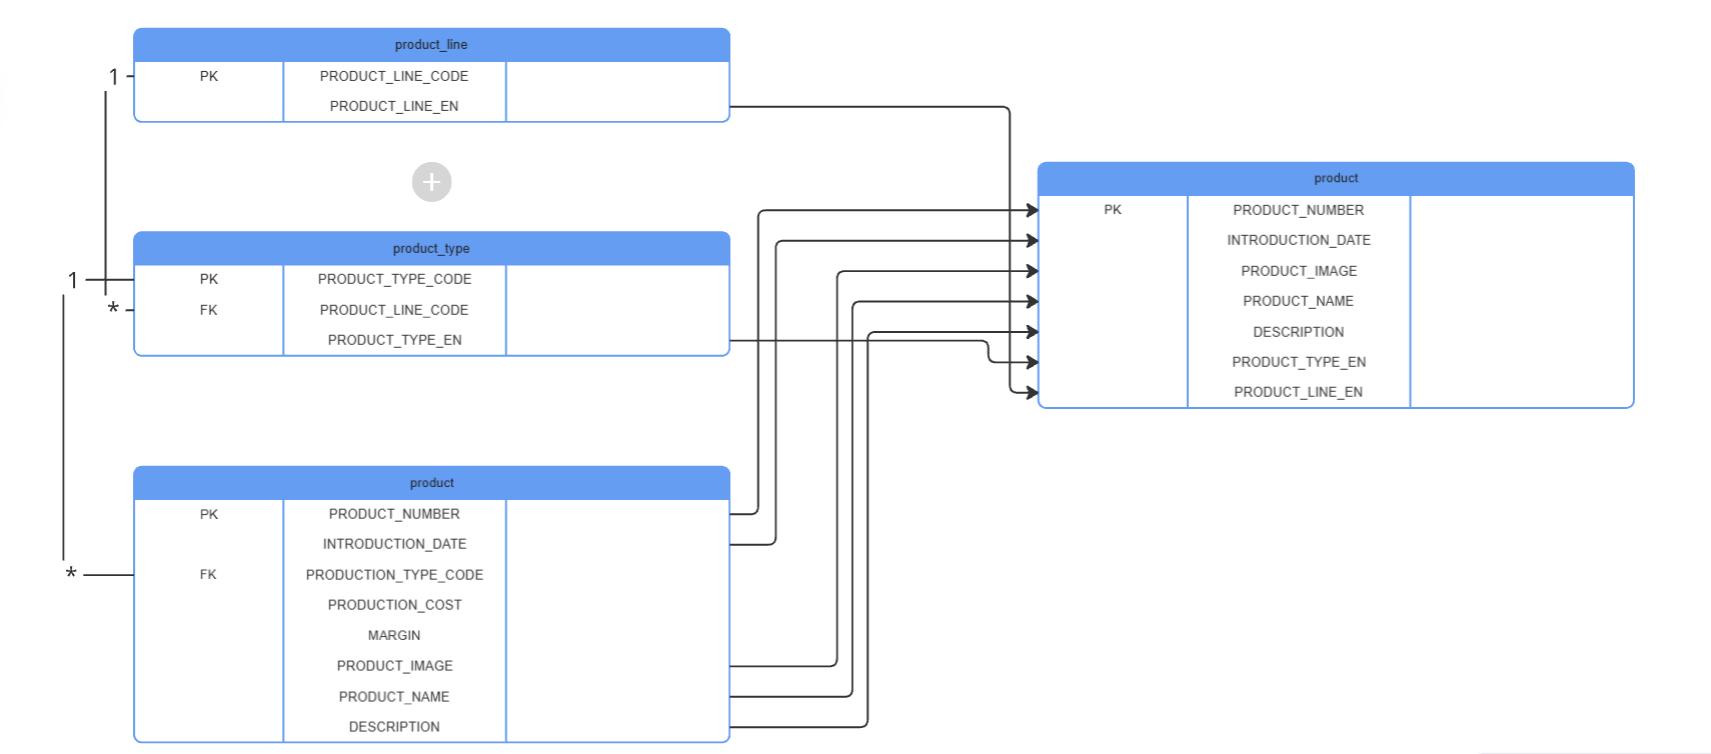

In [1349]:
df_product = pd.read_sql_query("SELECT * FROM Product", sdm_conn)
df_product_type = pd.read_sql_query("SELECT * FROM Product_Type", sdm_conn)
df_product_line = pd.read_sql_query("SELECT * FROM Product_Line", sdm_conn)

df_product_type_final = pd.merge(
    df_product_type,
    df_product_line,
    on='PRODUCT_LINE_CODE',
    how='left'
)

# 2. Merge only with those specific columns
df_product_final = pd.merge(
    df_product,
    df_product_type_final,
    on='PRODUCT_TYPE_CODE',
    how='left'
)

df_product_final = df_product_final.rename(columns={
    'PRODUCT_TYPE_EN': 'PRODUCT_TYPE',
    'PRODUCT_LINE_EN': 'PRODUCT_LINE'
})

# Force Pandas to parse the text dates using the exact format matching your data
df_product_final['INTRODUCTION_DATE'] = pd.to_datetime(
   df_product_final['INTRODUCTION_DATE'] , 
    format='%d-%b-%Y %I:%M:%S %p', 
    errors='coerce'
)


df_product_final = df_product_final[[
    'PRODUCT_NUMBER',
    'INTRODUCTION_DATE',
    'PRODUCT_IMAGE',
    'PRODUCT_NAME',
    'DESCRIPTION',
    'PRODUCT_TYPE',
    'PRODUCT_LINE'
]]
df_product_final


,PRODUCT_NUMBER,INTRODUCTION_DATE,PRODUCT_IMAGE,PRODUCT_NAME,DESCRIPTION,PRODUCT_TYPE,PRODUCT_LINE
0,53,2024-01-10,P53ME2CA8.jpg,Firefly Climbing Lamp,This climbing lamp is water-resistant. It come...,Climbing Accessories,Mountaineering Equipment
1,54,2024-01-10,P54ME2CA8.jpg,Firefly Charger,Power charger for the Firefly Climbing Lamp. T...,Climbing Accessories,Mountaineering Equipment
2,55,2024-01-10,P55ME2CA8.jpg,Firefly Rechargeable Battery,Rechargeable battery pack for the Firefly Clim...,Climbing Accessories,Mountaineering Equipment
3,56,2024-01-10,P56ME2CA8.jpg,Granite Chalk Bag,Nylon web bag perfect for holding several stic...,Climbing Accessories,Mountaineering Equipment
4,57,2024-01-10,P57ME2TL9.jpg,Granite Ice,A general purpose mountaineering axe for snow ...,Tools,Mountaineering Equipment
...,...,...,...,...,...,...,...
110,108,2022-12-27,P106GE5WD19.jpg,Lady Hailstorm Steel Woods Set,These steel woods are manufactured to exact to...,Woods,Golf Equipment
111,109,2022-12-10,P109GE5PT20.jpg,Course Pro Putter,High quality putter is cast from a soft yello...,Putters,Golf Equipment
112,110,2022-12-10,P110GE5PT20.jpg,Blue Steel Putter,This premium putter has copper mixed with ligh...,Putters,Golf Equipment
113,111,2022-12-15,P111GE5PT20.jpg,Blue Steel Max Putter,Putter head is composed from a single piece of...,Putters,Golf Equipment


In [1333]:
import sqlite3
import pandas as pd

# Ensure target_WH_db is defined earlier in your script
dwh_conn = sqlite3.connect(target_WH_db)

try:
    # 1. Read DWH and normalize columns
    df_dwh = pd.read_sql("SELECT * FROM Product", dwh_conn)
    df_dwh.columns = df_dwh.columns.str.lower()
    
    # Normalize source columns
    src_df = df_product_final.copy()
    src_df.columns = src_df.columns.str.lower()

    # --- FIX: TYPE ALIGNMENT & TYPO ---
    # Convert SDM strings to numeric
    src_df['product_number'] = pd.to_numeric(src_df['product_number'], errors='coerce')
    
    # FIXED: Changed 'customer_contract_code' to 'customer_contact_code'
    src_df = src_df.dropna(subset=['product_number'])
    src_df['product_number'] = src_df['product_number'].astype(int)
    # ---------------------------

    # 2. DETECT NEW ROWS
    new_rows = src_df[~src_df['product_number'].isin(df_dwh['product_number'])]

    # 3. DETECT CHANGES
    comparison = pd.merge(
        src_df, 
        df_dwh, 
        on='product_number', 
        suffixes=('_src', '_dwh')
    )

    # Columns to check for changes
    cols_to_check = ['introduction_date', 'product_image', 'product_name', 'description', 'product_type', 'product_line']

    # Vectorized comparison
    # We use .fillna('') and .astype(str) to prevent NaN != NaN false positives
    src_comp = comparison[[f"{c}_src" for c in cols_to_check]].fillna('').astype(str)
    dwh_comp = comparison[[f"{c}_dwh" for c in cols_to_check]].fillna('').astype(str)

    # DEBUG: Print the first 5 differences to see why it's flagging them
    for c in cols_to_check:
    # Convert both to numeric where possible, then to string to handle NaNs/Floats consistently
    # This turns 234.0 (float) and '234' (str) both into '234'
        comparison[f"{c}_src"] = pd.to_numeric(comparison[f"{c}_src"], errors='coerce').fillna(0).astype(int).astype(str)
        comparison[f"{c}_dwh"] = pd.to_numeric(comparison[f"{c}_dwh"], errors='coerce').fillna(0).astype(int).astype(str)

    # 2. Vectorized comparison
    src_comp = comparison[[f"{c}_src" for c in cols_to_check]]
    dwh_comp = comparison[[f"{c}_dwh" for c in cols_to_check]]
        
    changed_mask = (src_comp.values != dwh_comp.values).any(axis=1)
    changed_rows = comparison[changed_mask]

    # 4. THE LOAD
    if not new_rows.empty:
        # Only keep the original columns for the insert
        cols_to_keep = [c.lower() for c in df_product_final.columns]
        new_rows_to_insert = new_rows[cols_to_keep]
        new_rows_to_insert.to_sql('Product', dwh_conn, if_exists='append', index=False)
        print(f"✨ Inserted {len(new_rows)} new product records.")

    if not changed_rows.empty:
        cursor = dwh_conn.cursor()
        
        # Prepare batch update data
        update_data = []
        for _, row in changed_rows.iterrows():
            update_data.append((
                row['introduction_date_src'], 
                row['product_image_src'], 
                row['product_name_src'],
                row['description_src'],
                row['product_type_src'],
                row['product_line_src'],
                int(row['product_number']) # The ID for the WHERE clause
            ))

        sql = """
             UPDATE Product 
            SET introduction_date = ?, product_image = ?, product_name = ?, description = ?, product_type = ?, product_line = ?
            WHERE product_number = ?
        """
        cursor.executemany(sql, update_data)
        dwh_conn.commit()
        print(f"🔄 Updated {len(changed_rows)} existing rows (SCD Type 1).")
    
    if new_rows.empty and changed_rows.empty:
        print("ℹ️ No changes detected between SDM and DWH.")

except Exception as e:
    print(f"❌ An error occurred: {e}")

finally:
    dwh_conn.close()
    print("🔌 Connection closed safely.")

✨ Inserted 115 new product records.
🔌 Connection closed safely.


# Order

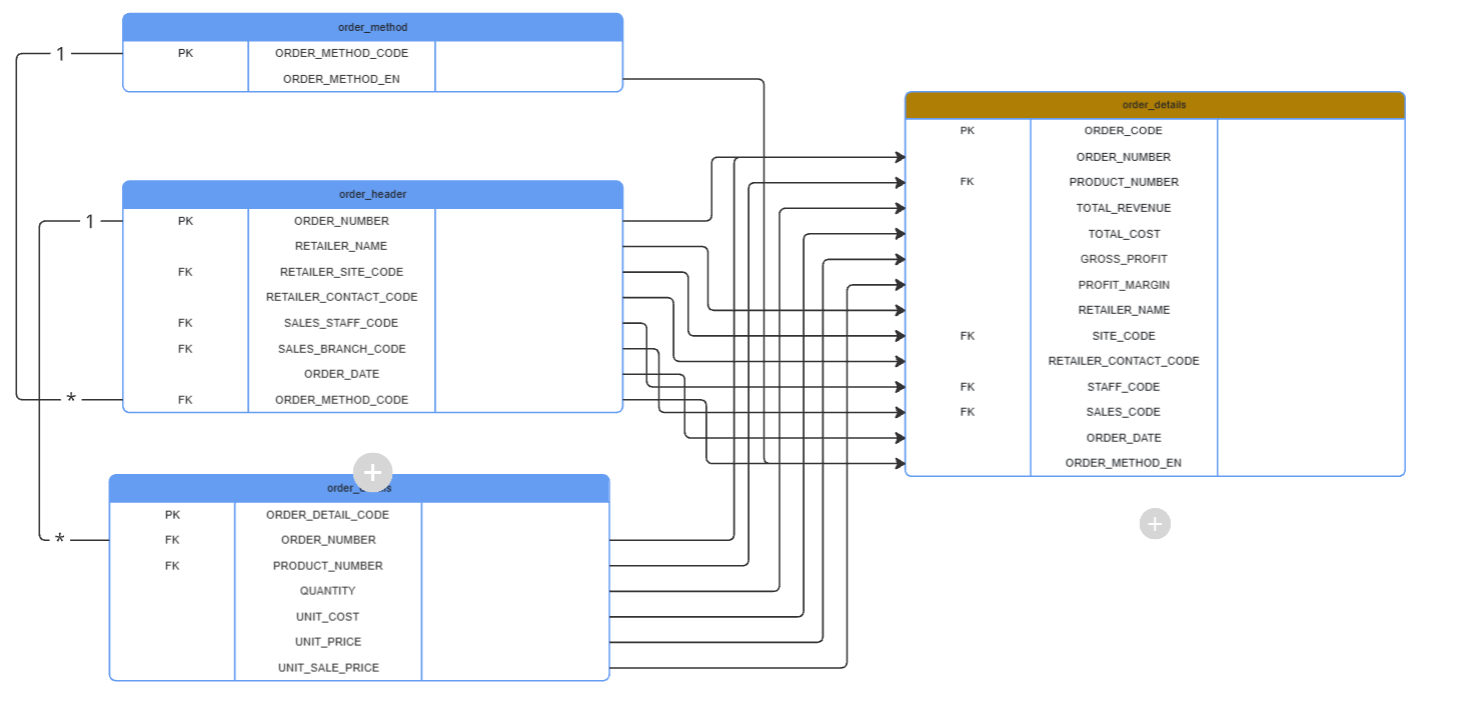

In [1350]:
df_order_method = pd.read_sql_query("SELECT * FROM Order_Method", sdm_conn)
df_order_header = pd.read_sql_query("SELECT * FROM Order_Header", sdm_conn)
df_order_details = pd.read_sql_query("SELECT * FROM Order_Details", sdm_conn)

df_order_header_final = pd.merge(
    df_order_header,
    df_order_method,
    on='ORDER_METHOD_CODE',
    how='left'
)

# 2. Merge only with those specific columns
df_order_final = pd.merge(
    df_order_details,
    df_order_header_final,
    on='ORDER_NUMBER',
    how='left'
)
# 1.3 making a turnover column 
# Ensure numeric types first
df_order_final['QUANTITY'] = pd.to_numeric(df_order_final['QUANTITY'], errors='coerce')
df_order_final['UNIT_SALE_PRICE'] = pd.to_numeric(df_order_final['UNIT_SALE_PRICE'], errors='coerce')
df_order_final['UNIT_COST'] = pd.to_numeric(df_order_final['UNIT_COST'], errors='coerce')

# Calculations (Fixed 'UNT_COST' to 'UNIT_COST')
df_order_final['TOTAL_REVENUE'] = df_order_final['QUANTITY'] * df_order_final['UNIT_SALE_PRICE']
df_order_final['TOTAL_COST'] = df_order_final['QUANTITY'] * df_order_final['UNIT_COST']
df_order_final['GROSS_PROFIT'] = df_order_final['TOTAL_REVENUE'] - df_order_final['TOTAL_COST']
df_order_final['PROFIT_MARGIN'] = (df_order_final['GROSS_PROFIT'] / df_order_final['TOTAL_REVENUE'])*100


# 1.2 Fix the column names
# Both tables likely have a 'naam' column, so Pandas makes them 'naam_x' and 'naam_y'
df_order_final = df_order_final.rename(columns={
    'RETAILER_SITE_CODE': 'SITE_CODE',
    'ORDER_DETAIL_CODE': 'ORDER_CODE',
    'SALES_STAFF_CODE': 'STAFF_CODE',
    'SALES_BRANCH_CODE': 'SALES_CODE',
    'ORDER_METHOD_EN': 'ORDER_METHOD'
})

# Force Pandas to parse the text dates using the exact format matching your data
df_order_final['ORDER_DATE'] = pd.to_datetime(
    df_order_final['ORDER_DATE'] , 
    format='%d-%b-%Y %I:%M:%S %p', 
    errors='coerce'
)


df_order_final = df_order_final[[
    'ORDER_CODE',
    'ORDER_NUMBER',
    'PRODUCT_NUMBER',
    'QUANTITY',
    'TOTAL_REVENUE',
    'TOTAL_COST',
    'GROSS_PROFIT',
    'PROFIT_MARGIN',
    'RETAILER_NAME',
    'SITE_CODE',
    'RETAILER_CONTACT_CODE',
    'STAFF_CODE',
    'SALES_CODE',
    'ORDER_DATE',
    'ORDER_METHOD'
]]
df_order_final


,ORDER_CODE,ORDER_NUMBER,PRODUCT_NUMBER,QUANTITY,TOTAL_REVENUE,TOTAL_COST,GROSS_PROFIT,PROFIT_MARGIN,RETAILER_NAME,SITE_CODE,RETAILER_CONTACT_CODE,STAFF_CODE,SALES_CODE,ORDER_DATE,ORDER_METHOD
0,48616,1258,17,92,7210.04,5546.68,1663.36,23.070052,VIP Department Stores,13,70,50,18,2024-10-14,Sales visit
1,48617,1352,17,190,12745.20,11455.10,1290.10,10.122242,Falcon Outfitters,17,73,52,18,2024-06-20,Telephone
2,48618,1544,17,82,6426.34,4943.78,1482.56,23.070052,VIP Department Stores,13,70,50,18,2024-11-24,Telephone
3,48619,1249,17,190,13729.40,11455.10,2274.30,16.565181,Ultra Sports,4,6,49,18,2024-04-02,Web
4,48620,1268,17,152,11863.60,9164.08,2699.52,22.754644,Falcon Outfitters,19,4,49,18,2024-10-10,Sales visit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40985,102951,8614,11,16,5200.00,4000.00,1200.00,23.076923,Sport Jonas,267,264,27,15,2025-09-08,E-mail
40986,102952,8611,11,18,6300.00,4500.00,1800.00,28.571429,Sport Jonas,265,262,28,15,2025-10-01,Web
40987,102953,8591,11,18,5850.00,4500.00,1350.00,23.076923,Campingspecialisten,261,258,27,15,2025-07-23,Sales visit
40988,102954,8619,11,18,6300.00,4500.00,1800.00,28.571429,Sport Jonas,268,265,28,15,2025-03-31,Web


In [1335]:
import sqlite3
import pandas as pd

# Ensure target_WH_db is defined earlier in your script
dwh_conn = sqlite3.connect(target_WH_db)

try:
    # 1. Read DWH and normalize columns
    df_dwh = pd.read_sql("SELECT * FROM Orders", dwh_conn)
    df_dwh.columns = df_dwh.columns.str.lower()
    
    # Normalize source columns
    src_df = df_order_final.copy()
    src_df.columns = src_df.columns.str.lower()

    # --- FIX: TYPE ALIGNMENT & TYPO ---
    # Convert SDM strings to numeric
    src_df['order_code'] = pd.to_numeric(src_df['order_code'], errors='coerce')
    
    # FIXED: Changed 'customer_contract_code' to 'customer_contact_code'
    src_df = src_df.dropna(subset=['order_code'])
    src_df['order_code'] = src_df['order_code'].astype(int)
    # ---------------------------

    # 2. DETECT NEW ROWS
    new_rows = src_df[~src_df['order_code'].isin(df_dwh['order_code'])]

    # 3. DETECT CHANGES
    comparison = pd.merge(
        src_df, 
        df_dwh, 
        on='order_code', 
        suffixes=('_src', '_dwh')
    )

    # Columns to check for changes
    cols_to_check = ['order_number', 'product_number', 'quantity', 'total_revenue', 'total_cost', 'gross_profit', 'profit_margin', 'retailer_name', 'site_code', 'retailer_contact_code', 'staff_code', 'sales_code', 'order_date', 'order_method']

    # Vectorized comparison
    # We use .fillna('') and .astype(str) to prevent NaN != NaN false positives
    src_comp = comparison[[f"{c}_src" for c in cols_to_check]].fillna('').astype(str)
    dwh_comp = comparison[[f"{c}_dwh" for c in cols_to_check]].fillna('').astype(str)
    
    changed_mask = (src_comp.values != dwh_comp.values).any(axis=1)
    changed_rows = comparison[changed_mask]

    # 4. THE LOAD
    if not new_rows.empty:
        # Only keep the original columns for the insert
        cols_to_keep = [c.lower() for c in df_order_final.columns]
        new_rows_to_insert = new_rows[cols_to_keep]
        new_rows_to_insert.to_sql('Orders', dwh_conn, if_exists='append', index=False)
        print(f"✨ Inserted {len(new_rows)} new order records.")

    if not changed_rows.empty:
        cursor = dwh_conn.cursor()
        
        # Prepare batch update data
        update_data = []
        for _, row in changed_rows.iterrows():
            update_data.append((
                row['order_number_src'], 
                row['product_number_src'], 
                row['quantity'],
                row['total_revenue_src'], 
                row['total_cost_src'], 
                row['gross_profit_src'],
                row['profit_margin_src'],
                row['retailer_name_src'],
                row['site_code_src'],
                row['retailer_contact_code_src'],
                row['staff_code_src'],
                row['sales_code_src'],
                row['order_date_src'],
                row['order_method_src'],
                int(row['order_code']) # The ID for the WHERE clause
            ))

        sql = """
            UPDATE Orders 
            SET order_number = ?, product_number = ?, quantity = ?, total_revenue = ?, total_cost = ?, gross_profit = ?, profit_margin = ?, retailer_name = ?, site_code = ?, retailer_contact_code = ?, staff_code = ?, sales_code = ?, order_date = ?, order_method = ?
            WHERE order_code = ?
        """
        cursor.executemany(sql, update_data)
        dwh_conn.commit()
        print(f"🔄 Updated {len(changed_rows)} existing rows (SCD Type 1).")
    
    if new_rows.empty and changed_rows.empty:
        print("ℹ️ No changes detected between SDM and DWH.")

except Exception as e:
    print(f"❌ An error occurred: {e}")

finally:
    dwh_conn.close()
    print("🔌 Connection closed safely.")

✨ Inserted 40990 new order records.
🔌 Connection closed safely.


# Returned Item

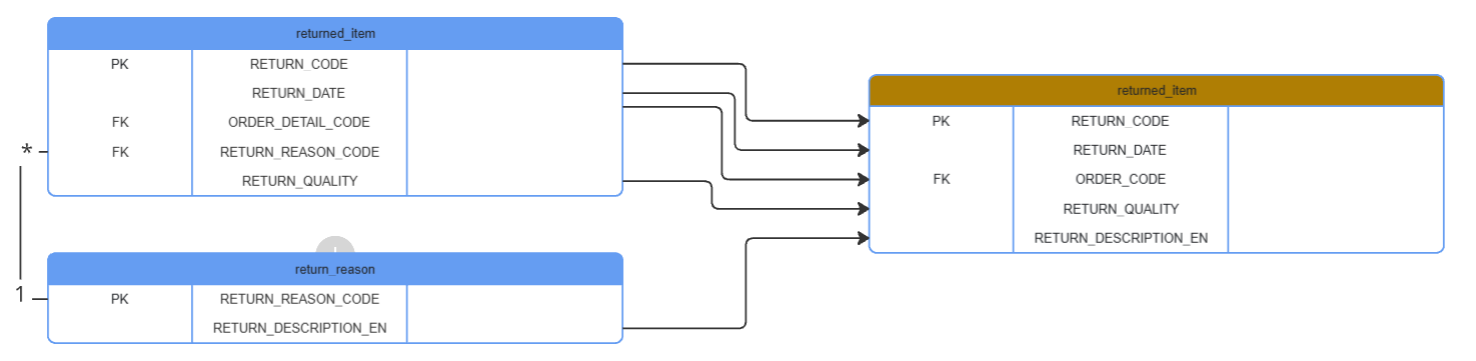

In [ ]:
df_returned_item = pd.read_sql_query("SELECT * FROM Returned_Item", sdm_conn)
df_return_reason = pd.read_sql_query("SELECT * FROM Return_Reason", sdm_conn)


df_returned_item_final = pd.merge(
    df_returned_item,
    df_return_reason,
    on='RETURN_REASON_CODE',
    how='left'
)

df_returned_item_final = df_returned_item_final.rename(columns={
    'ORDER_DETAIL_CODE': 'ORDER_CODE',
    'RETURN_DESCRIPTION_EN': 'RETURN_DESCRIPTION'
})

# Force Pandas to parse the text dates using the exact format matching your data
df_returned_item_final['RETURN_DATE'] = pd.to_datetime(
    df_returned_item_final['RETURN_DATE'] , 
    format='%d-%b-%Y %I:%M:%S %p', 
    errors='coerce'
)

df_returned_item_final = df_returned_item_final[[
    'RETURN_CODE',
    'RETURN_DATE',
    'ORDER_CODE',
    'RETURN_QUANTITY',
    'RETURN_DESCRIPTION'
]]

df_returned_item_final

,RETURN_CODE,RETURN_DATE,ORDER_CODE,RETURN_QUANTITY,RETURN_DESCRIPTION
0,1491,01-Aug-2024 04:10:24 AM,84858,8,Unsatisfactory product
1,1492,06-Dec-2023 06:46:19 PM,84440,2,Incomplete product
2,1493,24-Jun-2024 09:23:14 AM,84867,22,Wrong product shipped
3,1494,21-Jul-2024 12:00:09 AM,84873,20,Wrong product ordered
4,1496,07-Oct-2023 05:13:58 AM,84488,2,Defective product
...,...,...,...,...,...
685,2465,06-Jun-2024 09:22:12 AM,114972,24,Wrong product ordered
686,2466,06-Oct-2024 12:31:25 PM,114983,66,Unsatisfactory product
687,2467,31-Mar-2025 03:39:38 PM,115215,64,Wrong product shipped
688,2468,23-Dec-2025 07:48:50 PM,115171,2,Defective product


In [1337]:
import sqlite3
import pandas as pd

# Ensure target_WH_db is defined earlier in your script
dwh_conn = sqlite3.connect(target_WH_db)

try:
    # 1. Read DWH and normalize columns
    df_dwh = pd.read_sql("SELECT * FROM Returned_Item", dwh_conn)
    df_dwh.columns = df_dwh.columns.str.lower()
    
    # Normalize source columns
    src_df = df_returned_item_final.copy()
    src_df.columns = src_df.columns.str.lower()

    # --- FIX: TYPE ALIGNMENT & TYPO ---
    # Convert SDM strings to numeric
    src_df['return_code'] = pd.to_numeric(src_df['return_code'], errors='coerce')
    
    src_df = src_df.dropna(subset=['return_code'])
    src_df['return_code'] = src_df['return_code'].astype(int)
    # ---------------------------

    # 2. DETECT NEW ROWS
    new_rows = src_df[~src_df['return_code'].isin(df_dwh['return_code'])]

    # 3. DETECT CHANGES
    comparison = pd.merge(
        src_df, 
        df_dwh, 
        on='return_code', 
        suffixes=('_src', '_dwh')
    )

    # Columns to check for changes
    cols_to_check = ['return_date', 'order_code', 'return_quantity', 'return_description']

    # Vectorized comparison
    # We use .fillna('') and .astype(str) to prevent NaN != NaN false positives
    src_comp = comparison[[f"{c}_src" for c in cols_to_check]].fillna('').astype(str)
    dwh_comp = comparison[[f"{c}_dwh" for c in cols_to_check]].fillna('').astype(str)
    
    changed_mask = (src_comp.values != dwh_comp.values).any(axis=1)
    changed_rows = comparison[changed_mask]

    # 4. THE LOAD
    if not new_rows.empty:
        # Only keep the original columns for the insert
        cols_to_keep = [c.lower() for c in df_returned_item_final.columns]
        new_rows_to_insert = new_rows[cols_to_keep]
        new_rows_to_insert.to_sql('Returned_Item', dwh_conn, if_exists='append', index=False)
        print(f"✨ Inserted {len(new_rows)} new returned_items records.")

    if not changed_rows.empty:
        cursor = dwh_conn.cursor()
        
        # Prepare batch update data
        update_data = []
        for _, row in changed_rows.iterrows():
            update_data.append((
                row['return_date_src'], 
                row['order_code_src'], 
                row['return_quantity_src'], 
                row['return_description_src'], 
                int(row['return_code']) # The ID for the WHERE clause
            ))

        sql = """
            UPDATE Returned_Item 
            SET return_date = ?, order_code = ?, return_quantity = ?, return_description = ?
            WHERE return_code = ?
        """
        cursor.executemany(sql, update_data)
        dwh_conn.commit()
        print(f"🔄 Updated {len(changed_rows)} existing rows (SCD Type 1).")
    
    if new_rows.empty and changed_rows.empty:
        print("ℹ️ No changes detected between SDM and DWH.")

except Exception as e:
    print(f"❌ An error occurred: {e}")

finally:
    dwh_conn.close()
    print("🔌 Connection closed safely.")

✨ Inserted 690 new returned_items records.
🔌 Connection closed safely.


# Training

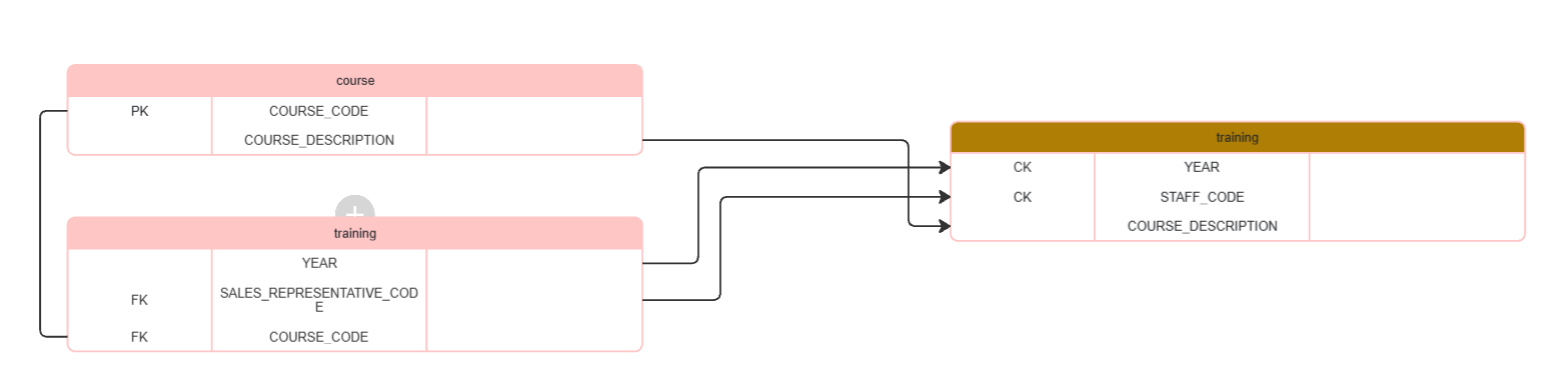

In [1338]:
df_course = pd.read_sql_query("SELECT * FROM Course", sdm_conn)
df_training = pd.read_sql_query("SELECT * FROM Training", sdm_conn)


df_training_final = pd.merge(
    df_training,
    df_course,
    on='COURSE_CODE',
    how='left'
)

df_training_final = df_training_final.rename(columns={
    'SALES_REPRESENTATIVE_CODE': 'STAFF_CODE'
})

df_training_final = df_training_final[[
    'YEAR',
    'STAFF_CODE',
    'COURSE_DESCRIPTION'
]]

df_training_final

,YEAR,STAFF_CODE,COURSE_DESCRIPTION
0,2004,4,GO Marketing 3
1,2006,4,GO Management 1
2,2006,5,GO Communication
3,2005,5,GO Sales 1
4,2005,5,GO Sales 2
...,...,...,...
397,2005,123,GO Marketing 3
398,2004,124,GO Communication
399,2004,124,GO Marketing 1
400,2005,124,GO Marketing 2


In [1339]:
import sqlite3
import pandas as pd

# Ensure target_WH_db and df_training_final are defined in your environment
dwh_conn = sqlite3.connect(target_WH_db)

try:
    # 1. Read DWH and normalize
    df_dwh = pd.read_sql("SELECT * FROM Training", dwh_conn)
    df_dwh.columns = df_dwh.columns.str.lower()
    
    src_df = df_training_final.copy()
    src_df.columns = src_df.columns.str.lower()

    # 2. Clean Types & Remove Duplicates in source
    src_df[['year', 'staff_code']] = src_df[['year', 'staff_code']].apply(pd.to_numeric, errors='coerce')
    src_df = src_df.dropna(subset=['year', 'staff_code'])
    src_df['year'] = src_df['year'].astype(int)
    src_df['staff_code'] = src_df['staff_code'].astype(int)
    
    # Ensure no duplicate keys in the source dataframe itself
    src_df = src_df.drop_duplicates(subset=['year', 'staff_code'])

    # 3. Detect New Rows
    combined = pd.merge(
        src_df, 
        df_dwh[['year', 'staff_code']], 
        on=['year', 'staff_code'], 
        how='left', 
        indicator=True
    )
    new_rows = combined[combined['_merge'] == 'left_only'].copy()

    # 4. Detect Changes
    comparison = pd.merge(
        src_df, 
        df_dwh, 
        on=['year', 'staff_code'], 
        suffixes=('_src', '_dwh')
    )
    changed_mask = (
        comparison['course_description_src'].fillna('').astype(str) != 
        comparison['course_description_dwh'].fillna('').astype(str)
    )
    changed_rows = comparison[changed_mask]

    # 5. The Load
    db_columns = ['year', 'staff_code', 'course_description']

    if not new_rows.empty:
        new_rows_to_insert = new_rows[db_columns]
        try:
            new_rows_to_insert.to_sql('Training', dwh_conn, if_exists='append', index=False)
            print(f"✨ Inserted {len(new_rows_to_insert)} new records.")
        except Exception as e:
            print(f"❌ Insert failed: {e}")
            print("💡 Check: Do all staff_codes exist in the Staff table?")

    if not changed_rows.empty:
        cursor = dwh_conn.cursor()
        update_data = [
            (str(row['course_description_src']), int(row['year']), int(row['staff_code']))
            for _, row in changed_rows.iterrows()
        ]
        sql = "UPDATE Training SET course_description = ? WHERE year = ? AND staff_code = ?"
        try:
            cursor.executemany(sql, update_data)
            dwh_conn.commit()
            print(f"🔄 Updated {len(changed_rows)} existing rows.")
        except sqlite3.Error as e:
            print(f"❌ Update failed: {e}")
    
    if new_rows.empty and changed_rows.empty:
        print("ℹ️ No changes detected.")

except Exception as e:
    print(f"❌ Critical Logic Error: {e}")

finally:
    dwh_conn.close()
    print("🔌 Connection closed safely.")

✨ Inserted 228 new records.
🔌 Connection closed safely.


# Satisfaction

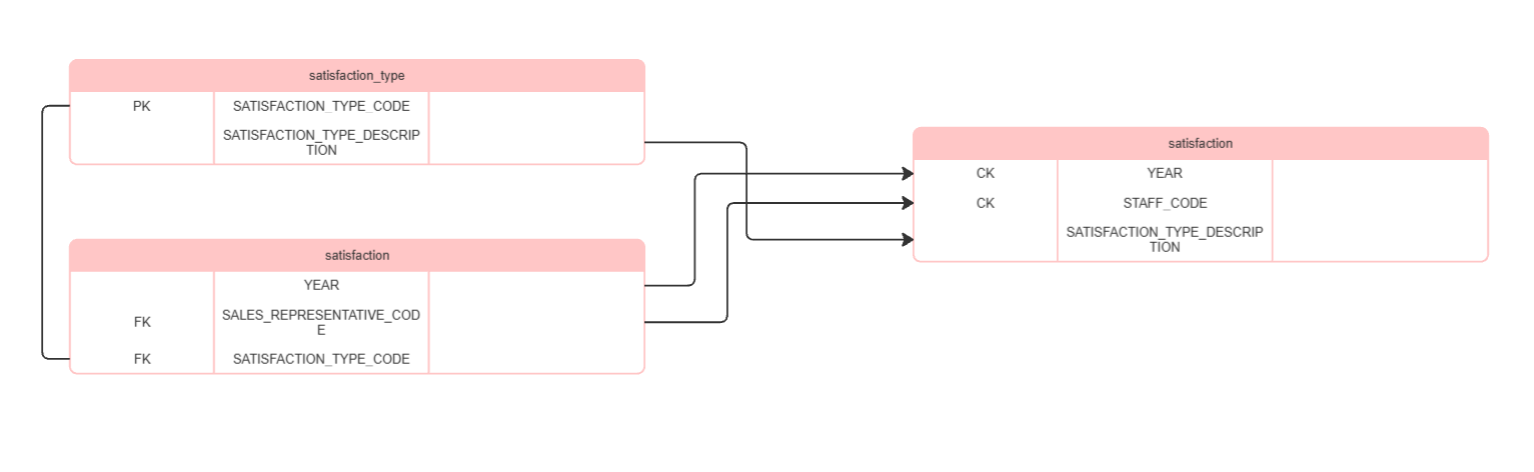

In [1340]:
df_satisfaction = pd.read_sql_query("SELECT * FROM Satisfaction", sdm_conn)
df_satisfaction_type = pd.read_sql_query("SELECT * FROM Satisfaction_Type", sdm_conn)


df_satisfaction_final = pd.merge(
    df_satisfaction,
    df_satisfaction_type,
    on='SATISFACTION_TYPE_CODE',
    how='left'
)

df_satisfaction_final = df_satisfaction_final.rename(columns={
    'SALES_REPRESENTATIVE_CODE': 'STAFF_CODE'
})

df_satisfaction_final = df_satisfaction_final[[
    'YEAR',
    'STAFF_CODE',
    'SATISFACTION_TYPE_DESCRIPTION'
]]

df_satisfaction_final

,YEAR,STAFF_CODE,SATISFACTION_TYPE_DESCRIPTION
0,2004,4,More than satisfied
1,2004,5,Very Satisfied
2,2004,6,Satisfied
3,2004,7,Very Satisfied
4,2004,12,Very Satisfied
...,...,...,...
296,2006,120,Very Satisfied
297,2006,121,Very Satisfied
298,2006,122,Very Satisfied
299,2006,123,Satisfied


In [1341]:
import sqlite3
import pandas as pd

# Ensure target_WH_db and df_satisfaction_final are defined in your environment
dwh_conn = sqlite3.connect(target_WH_db)

try:
    # 1. Read DWH and normalize
    df_dwh = pd.read_sql("SELECT * FROM Satisfaction", dwh_conn)
    df_dwh.columns = df_dwh.columns.str.lower()
    
    src_df = df_satisfaction_final.copy()
    src_df.columns = src_df.columns.str.lower()

    # 2. Clean Types & Remove Duplicates in source
    src_df[['year', 'staff_code']] = src_df[['year', 'staff_code']].apply(pd.to_numeric, errors='coerce')
    src_df = src_df.dropna(subset=['year', 'staff_code'])
    src_df['year'] = src_df['year'].astype(int)
    src_df['staff_code'] = src_df['staff_code'].astype(int)
    
    # Ensure no duplicate keys in the source dataframe itself
    src_df = src_df.drop_duplicates(subset=['year', 'staff_code'])

    # 3. Detect New Rows
    combined = pd.merge(
        src_df, 
        df_dwh[['year', 'staff_code']], 
        on=['year', 'staff_code'], 
        how='left', 
        indicator=True
    )
    new_rows = combined[combined['_merge'] == 'left_only'].copy()

    # 4. Detect Changes
    comparison = pd.merge(
        src_df, 
        df_dwh, 
        on=['year', 'staff_code'], 
        suffixes=('_src', '_dwh')
    )
    changed_mask = (
        comparison['satisfaction_type_description_src'].fillna('').astype(str) != 
        comparison['satisfaction_type_description_dwh'].fillna('').astype(str)
    )
    changed_rows = comparison[changed_mask]

    # 5. The Load
    db_columns = ['year', 'staff_code', 'satisfaction_type_description']

    if not new_rows.empty:
        new_rows_to_insert = new_rows[db_columns]
        try:
            new_rows_to_insert.to_sql('Satisfaction', dwh_conn, if_exists='append', index=False)
            print(f"✨ Inserted {len(new_rows_to_insert)} new records.")
        except Exception as e:
            print(f"❌ Insert failed: {e}")
            print("💡 Check: Do all staff_codes exist in the Staff table?")

    if not changed_rows.empty:
        cursor = dwh_conn.cursor()
        update_data = [
            (str(row['satisfaction_type_description_src']), int(row['year']), int(row['staff_code']))
            for _, row in changed_rows.iterrows()
        ]
        sql = "UPDATE Satisfaction SET satisfaction_type_description = ? WHERE year = ? AND staff_code = ?"
        try:
            cursor.executemany(sql, update_data)
            dwh_conn.commit()
            print(f"🔄 Updated {len(changed_rows)} existing rows.")
        except sqlite3.Error as e:
            print(f"❌ Update failed: {e}")
    
    if new_rows.empty and changed_rows.empty:
        print("ℹ️ No changes detected.")

except Exception as e:
    print(f"❌ Critical Logic Error: {e}")

finally:
    dwh_conn.close()
    print("🔌 Connection closed safely.")

ℹ️ No changes detected.
🔌 Connection closed safely.


# Inventory_Forecast_Target 

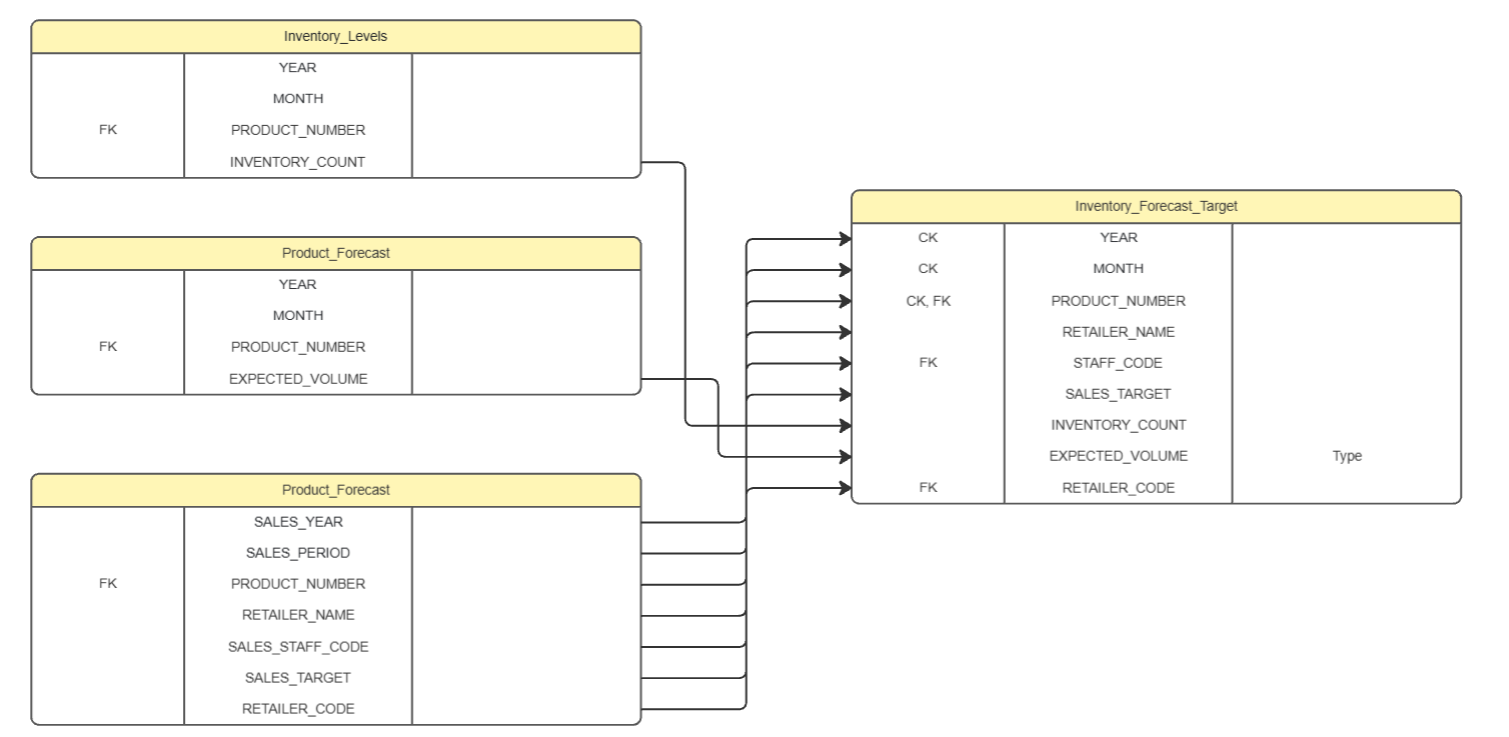

In [1342]:
df_inventory = pd.read_sql_query("SELECT * FROM Inventory_Levels", sdm_conn)
df_product_forecast = pd.read_sql_query("SELECT * FROM Product_Forecast", sdm_conn)
df_sales_target = pd.read_sql_query("SELECT * FROM Sales_Target", sdm_conn)



df_inventory = df_inventory.rename(columns={
    'INVENTORY_YEAR': 'YEAR',
    'INVENTORY_MONTH': 'MONTH'
})

df_inventory = df_inventory[[
    'YEAR',
    'MONTH',
    'PRODUCT_NUMBER',
    'INVENTORY_COUNT'
]]


df_product_forecast = df_product_forecast.rename(columns={
    'INVENTORY_YEAR': 'YEAR',
    'INVENTORY_MONTH': 'MONTH'
})

df_product_forecast = df_product_forecast[[
    'YEAR',
    'MONTH',
    'PRODUCT_NUMBER',
    'EXPECTED_VOLUME'
]]


df_inventory_forecast = pd.merge(
        df_inventory, 
        df_product_forecast, 
        on=['YEAR', 'MONTH', 'PRODUCT_NUMBER'], 
        how='left', 
    )



df_sales_target = df_sales_target.rename(columns={
    'SALES_YEAR': 'YEAR',
    'SALES_PERIOD': 'MONTH',
    'SALES_STAFF_CODE': 'STAFF_CODE'
})

df_inventory_forecast_target = pd.merge(
        df_inventory_forecast, 
        df_sales_target, 
        on=['YEAR', 'MONTH', 'PRODUCT_NUMBER'], 
        how='left', 
)

df_inventory_forecast_target = df_inventory_forecast_target[[
    'YEAR',
    'MONTH',
    'PRODUCT_NUMBER',
    'RETAILER_NAME',
    'STAFF_CODE',
    'SALES_TARGET',
    'INVENTORY_COUNT',
    'EXPECTED_VOLUME',
    'RETAILER_CODE'
]]

df_inventory_forecast_target

,YEAR,MONTH,PRODUCT_NUMBER,RETAILER_NAME,STAFF_CODE,SALES_TARGET,INVENTORY_COUNT,EXPECTED_VOLUME,RETAILER_CODE
0,2024,4,48,In die Berge!,16.0,1200.0,1932,128.0,54.0
1,2024,4,48,NonSoloNeve,21.0,1013.0,1932,128.0,147.0
2,2024,4,48,NonSoloNeve,19.0,358.0,1932,128.0,147.0
3,2024,4,48,Preben's Tøy,27.0,395.0,1932,128.0,161.0
4,2024,4,48,Preben's Tøy,28.0,315.0,1932,128.0,161.0
...,...,...,...,...,...,...,...,...,...
39549,2025,12,115,Hanagata Golf Shop,85.0,1037.0,3310,759.0,132.0
39550,2025,12,115,Hurst Ironmongers,114.0,683.0,3310,759.0,180.0
39551,2025,12,115,Hansung Golf,101.0,1658.0,3310,759.0,170.0
39552,2025,12,115,Hanagata Golf Shop,88.0,200.0,3310,759.0,132.0


In [1343]:
import sqlite3
import pandas as pd

# Ensure target_WH_db and df_sales_target are defined in your environment
dwh_conn = sqlite3.connect(target_WH_db)

try:
    # 1. Read DWH and normalize
    df_dwh = pd.read_sql("SELECT * FROM Inventory_Forecast_Target", dwh_conn)
    df_dwh.columns = df_dwh.columns.str.lower()
    
    src_df = df_inventory_forecast_target.copy()
    src_df.columns = src_df.columns.str.lower()

    # 2. Clean Types & Remove Duplicates in source
    src_df[['year', 'month', 'product_number']] = src_df[['year', 'month', 'product_number']].apply(pd.to_numeric, errors='coerce')
    src_df = src_df.dropna(subset=['year', 'month', 'product_number'])
    src_df['year'] = src_df['year'].astype(int)
    src_df['month'] = src_df['month'].astype(int)
    src_df['product_number'] = src_df['product_number'].astype(int)
    
    # Ensure no duplicate keys in the source dataframe itself
    src_df = src_df.drop_duplicates(subset=['year', 'month', 'product_number'])

    # 3. Detect New Rows
    combined = pd.merge(
        src_df, 
        df_dwh[['year', 'month', 'product_number']], 
        on=['year', 'month', 'product_number'], 
        how='left', 
        indicator=True
    )
    new_rows = combined[combined['_merge'] == 'left_only'].copy()

    # 4. Detect Changes
    comparison = pd.merge(
        src_df, 
        df_dwh, 
        on=['year', 'month', 'product_number'], 
        suffixes=('_src', '_dwh')
    )
    # Use the bitwise OR operator '|' to combine conditions into a single mask
    changed_mask = (
        (comparison['retailer_name_src'].fillna('').astype(str) != comparison['retailer_name_dwh'].fillna('').astype(str)) |
        (comparison['staff_code_src'].fillna(0).astype(int) != comparison['staff_code_dwh'].fillna(0).astype(int)) |
        (comparison['sales_target_src'].fillna(0).astype(int) != comparison['sales_target_dwh'].fillna(0).astype(int)) |
        (comparison['inventory_count_src'].fillna(0).astype(int) != comparison['inventory_count_dwh'].fillna(0).astype(int)) |
        (comparison['expected_volume_src'].fillna(0).astype(int) != comparison['expected_volume_dwh'].fillna(0).astype(int)) |
        (comparison['retailer_code_src'].fillna(0).astype(int) != comparison['retailer_code_dwh'].fillna(0).astype(int))
    )

    changed_rows = comparison[changed_mask]

    # 5. The Load
    db_columns = ['year', 'month', 'product_number', 'retailer_name', 'staff_code', 'sales_target', 'inventory_count', 'expected_volume','retailer_code']

    if not new_rows.empty:
        new_rows_to_insert = new_rows[db_columns]
        try:
            new_rows_to_insert.to_sql('Inventory_Forecast_Target', dwh_conn, if_exists='append', index=False)
            print(f"✨ Inserted {len(new_rows_to_insert)} new records.")
        except Exception as e:
            print(f"❌ Insert failed: {e}")
            print("💡 Check: Do all staff_codes exist in the Staff table?")

    if not changed_rows.empty:
        cursor = dwh_conn.cursor()
        update_data = [
            (str(row['retailer_name_src']), int(row['staff_code_src']), int(row['sales_target_src']), int(row['inventory_count_src']), int(row['expected_volume_src']), int(row['retailer_code_src']), int(row['year']), int(row['month']), int(row['product_number']))
            for _, row in changed_rows.iterrows()
        ]
        sql = "UPDATE Inventory_Forecast_Target SET retailer_name = ?, staff_code = ?, sales_target = ?, inventory_count = ?, expected_volume = ?, retailer_code = ? WHERE year = ? AND month = ? AND product_number = ?"
        try:
            cursor.executemany(sql, update_data)
            dwh_conn.commit()
            print(f"🔄 Updated {len(changed_rows)} existing rows.")
        except sqlite3.Error as e:
            print(f"❌ Update failed: {e}")
    
    if new_rows.empty and changed_rows.empty:
        print("ℹ️ No changes detected.")

except Exception as e:
    print(f"❌ Critical Logic Error: {e}")

finally:
    dwh_conn.close()
    print("🔌 Connection closed safely.")

ℹ️ No changes detected.
🔌 Connection closed safely.
